# 🔐 SecurityBERT — BERT-Based Security SLM from Scratch
**Agentic SOC v4 | Single-Model Architecture: MLM Pretrain → Supervised Fine-tune**

---

## Why BERT instead of GPT?

| | GPT (old Phase 1) | BERT (this notebook) |
|---|---|---|
| **Reads sequence** | Left-to-right only | Bidirectional (full context) |
| **Unsupervised task** | Next-token prediction | Masked Language Modeling |
| **Classification** | No natural mechanism | `[CLS]` token is purpose-built |
| **Weight transfer** | Thrown away after Phase 1 | Phase 1 weights bootstrap Phase 2 |
| **Anomaly score** | Prediction loss | Reconstruction loss (same idea, richer) |

## Architecture
```
RAW LOG SESSION
      │
      ▼
[Custom BPE Tokenizer]  — security-aware, trained on your data
      │
      ▼
[CLS] tok1 tok2 [MASK] tok4 ... [SEP]   ← 15% tokens masked
      │
      ▼
[Token Emb + Segment Emb + Positional Emb]
      │
      ▼
[Transformer Encoder × 6]               ← BIDIRECTIONAL, no causal mask
      │
      ├─► [MASK] positions → MLM Head → reconstruct token  (Phase 1 loss)
      │
      └─► [CLS] vector → Classification Heads              (Phase 2 loss)
                          ├─ ThreatCategory  (14 classes)
                          ├─ Severity        (5 classes)
                          ├─ Confidence      (4 classes)
                          ├─ TruePositive    (binary)
                          └─ AttackSurface   (8 multi-label)
```

## Two-Phase Training (same model, progressive)
```
Phase 1 — MLM Pretraining  (unsupervised, ~900k normal sessions)
      Encoder learns: what do normal log sequences look like?
      Anomaly score: MLM reconstruction loss on new sessions
      ↓ (weights saved)
Phase 2 — Fine-tuning  (supervised, ~100k labeled sessions)
      Load Phase 1 weights → attach classification heads → train
      Now encoder already understands logs, just needs to name the threats
```

⚠️ **Runtime → Change Runtime Type → T4 GPU before running**

# 🎓 Notebook Summary: SecurityBERT Agentic SOC

You have successfully built and trained a specialized Small Language Model (SLM) for security operations. Here is the architectural flow you implemented:

### 1. Data Pipeline
*   **Tokenizer**: Custom BPE trained on logs. Vocab size: ~400 (very compact). Knows concepts like `[IP_PORT]` and `[WIN_PATH]`.
*   **Dataset**:
    *   **Phase 1**: 900,000 normal sessions (Unlabeled).
    *   **Phase 2**: 100,000 labeled sessions (Mixed Normal + 14 Attack Types).

### 2. The Model (SecurityBERT)
*   **Architecture**: 6-layer Transformer Encoder (Bidirectional).
*   **Size**: ~9 Million parameters (Lightweight, runs fast on T4).
*   **Input**: Raw log text $\rightarrow$ Token IDs $\rightarrow$ Embeddings (Token + Position + Segment).

### 3. Training Strategy
| Phase | Task | Goal | Loss Function |
|---|---|---|---|
| **1. Pretraining** | **Masked Language Modeling (MLM)** | Learn "Normal" | CrossEntropy on masked tokens |
| **2. Fine-tuning** | **Multi-Head Classification** | Learn "Threats" | Weighted sum of 5 heads (Threat, Severity, etc.) |

### 4. The Result
*   **Anomaly Detection**: Uses MLM loss to spot unknown attacks (Zero-day detection).
*   **Threat Classification**: Identifies specific attack categories (e.g., *Ransomware*, *Phishing*) with high confidence.
*   **Artifacts**: You exported a deployment bundle (`.zip`) containing the model weights and config, ready for a production inference server.

In [ ]:
import string

# ─────────────────────────────────────────────────────────────────────────────
# IMPROVED DATASET: ADVERSARIAL FUZZING & AUGMENTATION
# Goal: Break the "perfect templates" to force the model to learn semantics
# ─────────────────────────────────────────────────────────────────────────────

class LogFuzzer:
    def __init__(self):
        self.users = [f'user_{i}' for i in range(1000)] # Expand to 1000 users
        self.hosts = [f'ws-{i:04d}' for i in range(5000)] # Expand to 5000 hosts
        self.procs = ['excel.exe', 'winword.exe', 'calculator.exe', 'notepad.exe',
                      'mspaint.exe', 'spotify.exe', 'discord.exe', 'docker.exe']
        self.noise_chars = list(string.punctuation)

    def fuzz_entity(self, text: str) -> str:
        """Replace standard entities with randomized ones to prevent memorization"""
        # Replace users
        if 'user=' in text:
            text = re.sub(r'user=[a-zA-Z0-9]+', f'user={random.choice(self.users)}', text)
        # Replace hosts
        if 'host=' in text:
            text = re.sub(r'host=[a-zA-Z0-9-]+', f'host={random.choice(self.hosts)}', text)
        # Replace random procs (if not a specific attack tool)
        if 'proc=' in text and '[LOLBIN]' not in text:
             # 50% chance to swap benign proc
            if random.random() < 0.5:
                text = re.sub(r'proc=[a-zA-Z0-9]+\.exe',
                              f'proc={random.choice(self.procs)}', text)
        return text

    def inject_noise(self, text: str, probability=0.1) -> str:
        """Simulate log corruption, syslog header variations, or broken pipes"""
        if random.random() > probability: return text

        tokens = text.split()
        # Action 1: Drop a token (simulates parsing error)
        if len(tokens) > 5 and random.random() < 0.3:
            idx = random.randint(0, len(tokens)-1)
            tokens.pop(idx)

        # Action 2: Insert garbage (simulates syslog noise)
        if random.random() < 0.3:
            noise = ''.join(random.choices(self.noise_chars, k=5))
            idx = random.randint(0, len(tokens))
            tokens.insert(idx, noise)

        return ' '.join(tokens)

# Instantiate fuzzer
fuzzer = LogFuzzer()

# Redefine generation to include fuzzing
def generate_robust_session(generator_func):
    raw_text = generator_func()
    # 1. Fuzz entities (User/Host diversity)
    text = fuzzer.fuzz_entity(raw_text)
    # 2. Inject noise (Robustness)
    text = fuzzer.inject_noise(text)
    return text

print("LogFuzzer ready. Comparison:")
base_text = office_session()
print(f"Original: {base_text[:100]}...")
print(f"Fuzzed:   {generate_robust_session(office_session)[:100]}...")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
# PART 1 — Setup

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, math, os, re, json, random, time
from dataclasses import dataclass, field
from collections import Counter
from contextlib import nullcontext
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import matplotlib.pyplot as plt

device      = 'cuda' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU — Runtime → Change Runtime Type → T4 GPU')

Device: cuda
GPU   : NVIDIA H100 80GB HBM3
VRAM  : 85.0 GB


---
# PART 2 — Custom Security Tokenizer

## Why custom BPE instead of tiktoken/GPT-2?
```
GPT-2 BPE was trained on web text. It has no concept of security entities.

  GPT-2:  '192.168.1.5:4444'  →  7 tokens  ['192', '.', '168', '.', '1', '.', '5:4444']
  Ours:   '192.168.1.5:4444'  →  1 token   [IP_PORT]

  GPT-2:  'powershell.exe'    →  4 tokens  ['power', 'shell', '.', 'exe']
  Ours:   'powershell.exe'    →  1 token   [LOLBIN]
```

## Pipeline
```
Stage 1: Regex pre-pass   →  canonical tokens for structured entities
Stage 2: BPE              →  merge frequent character pairs for free-text
```

## Special BERT tokens
```
[PAD]   — padding to fixed length
[UNK]   — unknown token
[CLS]   — prepended to every input; its final embedding = sequence summary
[SEP]   — appended to every input (BERT convention)
[MASK]  — replaces 15% of tokens during MLM pretraining
```

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CANONICAL PATTERNS
# Ordered: most-specific first (IP_PORT before IPV4, SHA256 before MD5)
# ─────────────────────────────────────────────────────────────────────────────

CANONICAL_PATTERNS = [
    # Network — IP_PORT MUST precede IPV4
    (r'\b(?:\d{1,3}\.){3}\d{1,3}:\d{1,5}\b',      '[IP_PORT]'),
    (r'\b(?:\d{1,3}\.){3}\d{1,3}\b',               '[IPV4]'),
    (r'https?://[^\s<>"]+',                         '[URL]'),
    (r'\b(?:[a-z0-9](?:[a-z0-9-]{0,61}[a-z0-9])?\.)+(?:com|org|net|io|gov|edu|xyz|ru|cn)\b',
                                                    '[DOMAIN]'),
    # Hashes — longer first
    (r'\b[0-9a-fA-F]{64}\b',                       '[HASH_SHA256]'),
    (r'\b[0-9a-fA-F]{40}\b',                       '[HASH_SHA1]'),
    (r'\b[0-9a-fA-F]{32}\b',                       '[HASH_MD5]'),
    # Time
    (r'\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})',
                                                    '[TIMESTAMP]'),
    # Threat intel
    (r'CVE-\d{4}-\d{4,7}',                         '[CVE]'),
    (r'T1\d{3}(?:\.\d{3})?',                       '[MITRE_TID]'),
    # Windows artefacts
    (r'[A-Z]:\\(?:[^\\\s:*?"<>|]+\\)*[^\\\s:*?"<>|]*', '[WIN_PATH]'),
    (r'\b(?:HKLM|HKCU|HKCR|HKU)\\[^\s]+',         '[REG_PATH]'),
    (r'\bEvent\s*ID[:\s]*\d{1,5}\b',              '[EVENT_ID]'),
    (r'\bPID[:\s]*\d+\b',                          '[PID]'),
    (r'\bSID[:\s]*S-\d-\d+-[\d-]+\b',             '[SID]'),
    # Linux paths
    (r'(?:/[\w\-\.]+){2,}/?',                      '[UNIX_PATH]'),
    # LOLBins
    (r'\b(?:powershell|cmd|wscript|cscript|rundll32|regsvr32|mshta|certutil|'
     r'bitsadmin|wmic|msiexec|msbuild|installutil|regasm|schtasks|'
     r'sc\.exe|net\.exe|whoami|ipconfig|nltest)\.exe\b', '[LOLBIN]'),
    # Ports
    (r'\bport[=:\s]\d{1,5}\b',                    '[PORT]'),
    # Protocols
    (r'\b(?:TCP|UDP|HTTP|HTTPS|SSH|RDP|FTP|SMB|DNS|LDAP|WMI|ICMP|TLS)\b',
                                                    '[PROTO]'),
]

_compiled = [(re.compile(p, re.IGNORECASE), t) for p, t in CANONICAL_PATTERNS]

def canonicalize(text: str) -> str:
    for pat, tok in _compiled:
        text = pat.sub(tok, text)
    return text

# Validation
TESTS = [
    ('192.168.1.5:4444',          '[IP_PORT]'),
    ('connect to 10.0.0.1',       '[IPV4]'),
    ('beacon.c2server.ru',        '[DOMAIN]'),
    ('CVE-2024-1234 T1059.001',   '[CVE]'),
    ('ran powershell.exe',        '[LOLBIN]'),
    ('Event ID: 4625',            '[EVENT_ID]'),
]
print('Pattern validation:')
for text, expected in TESTS:
    result = canonicalize(text)
    ok = '✓' if expected in result else '✗'
    print(f'  {ok}  "{text}"  →  "{result}"')

Pattern validation:
  ✓  "192.168.1.5:4444"  →  "[IP_PORT]"
  ✓  "connect to 10.0.0.1"  →  "connect to [IPV4]"
  ✓  "beacon.c2server.ru"  →  "[DOMAIN]"
  ✓  "CVE-2024-1234 T1059.001"  →  "[CVE] [MITRE_TID]"
  ✓  "ran powershell.exe"  →  "ran [LOLBIN]"
  ✓  "Event ID: 4625"  →  "[EVENT_ID]"


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECURITY BPE TOKENIZER
#
# Differences from standard BPE:
#   1. Security canonical tokens are pre-defined vocabulary — never merged
#   2. BERT special tokens: [PAD] [UNK] [CLS] [SEP] [MASK]
#   3. SOC-domain special tokens: [ALERT] [ANOMALY] etc.
#   4. train() takes raw log texts — learns BPE merges on your data
#   5. encode() produces input_ids + attention_mask + token_type_ids
# ─────────────────────────────────────────────────────────────────────────────

class SecurityBERTTokenizer:
    """
    Custom BPE tokenizer for security telemetry.

    Vocab layout:
      [0..4]    BERT special tokens (PAD, UNK, CLS, SEP, MASK)
      [5..44]   Security canonical tokens (IP_PORT, LOLBIN, etc.)
      [45..N]   BPE-learned subword tokens
    """

    # BERT core specials
    BERT_SPECIALS = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']

    # Security domain specials (canonical + SOC markers)
    SEC_SPECIALS = [
        # Canonical entity tokens
        '[IP_PORT]', '[IPV4]', '[URL]', '[DOMAIN]',
        '[HASH_SHA256]', '[HASH_SHA1]', '[HASH_MD5]',
        '[TIMESTAMP]', '[CVE]', '[MITRE_TID]',
        '[WIN_PATH]', '[REG_PATH]', '[EVENT_ID]', '[PID]', '[SID]',
        '[UNIX_PATH]', '[LOLBIN]', '[PORT]', '[PROTO]',
        # SOC pipeline markers
        '[ALERT]', '[ANOMALY]', '[BASELINE]', '[CORRELATION]',
        '[TRUE_POS]', '[FALSE_POS]',
        # Attack surface markers
        '[ENDPOINT]', '[NETWORK]', '[CLOUD]', '[EMAIL]',
        '[IDENTITY]', '[WEB]', '[IOT]', '[MOBILE]',
        # Log event type tokens (high frequency, worth pre-defining)
        '[SESSION_START]', '[SESSION_END]', '[USER_LOGIN]', '[USER_LOGOUT]',
        '[PROC_CREATE]', '[FILE_READ]', '[FILE_WRITE]', '[FILE_DELETE]',
        '[NET_CONN]', '[DNS_QUERY]', '[REGISTRY_WRITE]', '[SYSTEM_REBOOT]',
    ]

    def __init__(self, vocab_size: int = 8192, min_frequency: int = 2):
        self.vocab_size    = vocab_size
        self.min_frequency = min_frequency
        self.token_to_id: dict = {}
        self.id_to_token: dict = {}
        self.merges: list = []

        # Register all special tokens first
        all_specials = self.BERT_SPECIALS + self.SEC_SPECIALS
        for tok in all_specials:
            self._add(tok)

        # Convenience ID lookups
        self.pad_id  = self.token_to_id['[PAD]']
        self.unk_id  = self.token_to_id['[UNK]']
        self.cls_id  = self.token_to_id['[CLS]']
        self.sep_id  = self.token_to_id['[SEP]']
        self.mask_id = self.token_to_id['[MASK]']

        # Set of all special token strings (never BPE-merged)
        self._special_set = set(all_specials)

    def _add(self, token: str) -> int:
        if token not in self.token_to_id:
            idx = len(self.token_to_id)
            self.token_to_id[token] = idx
            self.id_to_token[idx]   = token
        return self.token_to_id[token]

    # ── Pre-tokenization ───────────────────────────────────────────────────

    def _pre_tokenize(self, text: str) -> list:
        """
        Split text into a list of tokens.
        Special tokens (bracket-enclosed) are kept whole.
        Everything else is split on whitespace.
        """
        # Match either [SPECIAL_TOKEN] or whitespace-separated words
        return re.findall(r'\[[A-Z_0-9]+\]|\S+', text)

    # ── BPE training ────────────────────────────────────────────────────────

    def _word_to_chars(self, word: str) -> list:
        """Split a word into characters, each as a separate list element."""
        return list(word.lower())

    def _merge_pair(self, corpus: list, pair: tuple, merged: str) -> list:
        """Apply one BPE merge across entire corpus."""
        new_corpus = []
        for word in corpus:
            new_word = []
            i = 0
            while i < len(word):
                if (i < len(word) - 1
                        and word[i] == pair[0]
                        and word[i+1] == pair[1]):
                    new_word.append(merged)
                    i += 2
                else:
                    new_word.append(word[i])
                    i += 1
            new_corpus.append(new_word)
        return new_corpus

    def train(self, texts: list, verbose: bool = True) -> dict:
        """
        Train BPE on a list of raw log texts.
        texts: list of strings (one session per string)
        """
        if verbose:
            print(f'[Tokenizer] Training on {len(texts):,} texts')
            print(f'[Tokenizer] Current vocab (specials): {len(self.token_to_id)}')
            print(f'[Tokenizer] Target vocab size: {self.vocab_size}')

        # Step 1: Build character vocabulary from non-special tokens
        char_freq = Counter()
        corpus    = []  # list of word-level char lists

        for text in texts:
            canonical = canonicalize(text)
            for tok in self._pre_tokenize(canonical):
                if tok in self._special_set:
                    continue  # specials already in vocab, skip
                chars = self._word_to_chars(tok)
                corpus.append(chars)
                for c in chars:
                    char_freq[c] += 1

        # Add frequent characters to vocab
        for char, freq in char_freq.items():
            if freq >= self.min_frequency:
                self._add(char)

        base_size = len(self.token_to_id)
        n_merges  = self.vocab_size - base_size

        if verbose:
            print(f'[Tokenizer] After chars: {base_size} tokens, need {n_merges} merges')

        # Step 2: BPE merge loop
        for i in range(max(0, n_merges)):
            # Count all adjacent pairs across corpus
            pair_freq = Counter()
            for word in corpus:
                for j in range(len(word) - 1):
                    pair_freq[(word[j], word[j+1])] += 1

            if not pair_freq:
                break

            best_pair, freq = pair_freq.most_common(1)[0]
            if freq < self.min_frequency:
                break

            merged = best_pair[0] + best_pair[1]
            self.merges.append(best_pair)
            self._add(merged)
            corpus = self._merge_pair(corpus, best_pair, merged)

            if verbose and (i + 1) % 500 == 0:
                print(f'  Merge {i+1:4d}/{n_merges}  "{best_pair[0]}" + "{best_pair[1]}" → "{merged}"  (freq={freq})')

        if verbose:
            print(f'[Tokenizer] ✅ Final vocab size: {len(self.token_to_id):,}')

        return {'vocab_size': len(self.token_to_id), 'n_merges': len(self.merges)}

    # ── BPE encoding ────────────────────────────────────────────────────────

    def _apply_bpe(self, word: str) -> list:
        """Apply learned merges to a single word."""
        pieces = list(word.lower())
        for l, r in self.merges:
            pieces = self._merge_pair([pieces], (l, r), l + r)[0]
        return pieces

    def encode(self,
               text: str,
               max_length: int = 128,
               padding: bool = True) -> dict:
        """
        Encode a log session string into BERT-format tensors.

        Returns:
          input_ids      — token IDs with [CLS] ... [SEP] [PAD]
          attention_mask — 1 for real tokens, 0 for padding
          token_type_ids — all zeros (single sequence, no NSP)
        """
        canonical = canonicalize(text)
        pre_tokens = self._pre_tokenize(canonical)

        ids = [self.cls_id]
        for tok in pre_tokens:
            if tok in self._special_set:
                ids.append(self.token_to_id.get(tok, self.unk_id))
            else:
                for piece in self._apply_bpe(tok):
                    ids.append(self.token_to_id.get(piece, self.unk_id))
        ids.append(self.sep_id)

        # Truncate (keep [CLS] and [SEP])
        if len(ids) > max_length:
            ids = ids[:max_length - 1] + [self.sep_id]

        attention_mask = [1] * len(ids)

        # Pad
        if padding and len(ids) < max_length:
            pad_len         = max_length - len(ids)
            ids            += [self.pad_id] * pad_len
            attention_mask += [0] * pad_len

        return {
            'input_ids':       ids,
            'attention_mask':  attention_mask,
            'token_type_ids':  [0] * len(ids),
        }

    def decode(self, ids: list) -> str:
        skip = {self.pad_id, self.cls_id, self.sep_id}
        return ' '.join(self.id_to_token.get(i, '[UNK]') for i in ids if i not in skip)

    def save(self, path: str):
        os.makedirs(os.path.dirname(path) if os.path.dirname(path) else '.', exist_ok=True)
        with open(path, 'w') as f:
            json.dump({
                'vocab_size':    self.vocab_size,
                'min_frequency': self.min_frequency,
                'token_to_id':   self.token_to_id,
                'merges':        self.merges,
            }, f)
        print(f'[Tokenizer] Saved → {path}  (vocab={len(self.token_to_id):,})')

    @classmethod
    def load(cls, path: str) -> 'SecurityBERTTokenizer':
        with open(path) as f:
            d = json.load(f)
        t = cls(d['vocab_size'], d['min_frequency'])
        t.token_to_id = d['token_to_id']
        t.id_to_token = {int(v): k for k, v in t.token_to_id.items()}
        t.merges      = [tuple(m) for m in d['merges']]
        t.pad_id      = t.token_to_id['[PAD]']
        t.unk_id      = t.token_to_id['[UNK]']
        t.cls_id      = t.token_to_id['[CLS]']
        t.sep_id      = t.token_to_id['[SEP]']
        t.mask_id     = t.token_to_id['[MASK]']
        return t


# Quick sanity check (train after data generation)
print('SecurityBERTTokenizer class defined ✅')
print(f'BERT specials: {SecurityBERTTokenizer.BERT_SPECIALS}')
print(f'Security specials: {len(SecurityBERTTokenizer.SEC_SPECIALS)} tokens')

SecurityBERTTokenizer class defined ✅
BERT specials: ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
Security specials: 45 tokens


---
# PART 3 — Data Generation (1M Sessions)

## Split
```
Total: 1,000,000 sessions
  ├── 900,000  normal   (unlabeled) → Phase 1 MLM pretraining
  └── 100,000  labeled  (attack + normal mix) → Phase 2 fine-tuning
        ├── 70,000  training
        └── 30,000  validation
```

## Labels (Phase 2)
Each labeled session carries:
- `threat_label`    — 14 MITRE-aligned threat categories
- `severity_label`  — 0=critical, 1=high, 2=medium, 3=low, 4=info
- `confidence_label`— 0=confirmed, 1=high, 2=medium, 3=low
- `tp_label`        — 1=true positive, 0=false positive
- `surface_labels`  — 8-bit multi-label (endpoint/network/cloud/email/...)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# NORMAL SESSION GENERATORS
# Covers: office work, admin tasks, dev work, file sharing,
#         patch management, DNS activity, cloud sync, VPN, DB queries
# ─────────────────────────────────────────────────────────────────────────────

USERS   = [f'user={u}' for u in ['jsmith','agarcia','blee','mwong','rthomas',
                                   'cwilson','pkumar','tnguyen','sfoster','dlopez']]
HOSTS   = [f'host={h}' for h in ['ws-042','ws-117','ws-203','laptop-88','laptop-12',
                                   'srv-dc01','srv-db02','srv-web03','mac-05','mac-16']]
PORTS   = {'http':80, 'https':443, 'smb':445, 'ldap':389, 'rdp':3389,
           'ssh':22, 'dns':53, 'smtp':25, 'kerberos':88, 'mssql':1433}
PROCS   = ['outlook.exe','chrome.exe','firefox.exe','explorer.exe',
           'code.exe','slack.exe','teams.exe','zoom.exe','git.exe']

def _u(): return random.choice(USERS)
def _h(): return random.choice(HOSTS)
def _p(): return random.choice(PROCS)
def _port(name): return PORTS[name]

def office_session():
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]',
          f'[USER_LOGIN] auth={random.choice(["password","sso","mfa"])}']
    for _ in range(random.randint(1,5)):
        ev.append(f'[FILE_READ] path=[WIN_PATH] proc={random.choice(["outlook.exe","word.exe","excel.exe"])}')
    for _ in range(random.randint(1,3)):
        ev.append(f'[NET_CONN] dst=[IPV4] [PORT] proc={random.choice(["chrome.exe","teams.exe"])} [PROTO]')
    ev += ['[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

def admin_session():
    u = random.choice(USERS)
    ev = [f'[SESSION_START] {u} host=srv-dc01 [TIMESTAMP]',
          '[USER_LOGIN] auth=kerberos',
          '[PROC_CREATE] proc=mmc.exe parent=svchost.exe']
    for _ in range(random.randint(1,4)):
        ev.append(f'[{random.choice(["FILE_READ","FILE_WRITE"])}] path=[WIN_PATH] proc=mmc.exe')
    ev += [f'[NET_CONN] dst=[IPV4] port={_port("ldap")} proc=mmc.exe [PROTO]',
           '[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

def dev_session():
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]',
          '[USER_LOGIN] auth=password',
          '[PROC_CREATE] proc=code.exe parent=explorer.exe']
    for _ in range(random.randint(2,7)):
        ev.append(f'[FILE_WRITE] path=[WIN_PATH] proc=code.exe')
    ev += ['[PROC_CREATE] proc=git.exe parent=code.exe',
           f'[NET_CONN] dst=[DOMAIN] port={_port("https")} proc=git.exe',
           '[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

def fileshare_session():
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]',
          '[USER_LOGIN] auth=ntlm',
          f'[NET_CONN] dst=[IPV4] port={_port("smb")} proc=explorer.exe']
    for _ in range(random.randint(2,6)):
        ev.append(f'[{random.choice(["FILE_READ","FILE_WRITE"])}] path=[WIN_PATH] proc=explorer.exe')
    ev += ['[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

def patch_session():
    h = _h()
    ev = [f'[SESSION_START] user=SYSTEM {h} [TIMESTAMP]',
          '[PROC_CREATE] proc=wuauclt.exe parent=svchost.exe',
          f'[NET_CONN] dst=[IPV4] port={_port("https")} proc=wuauclt.exe']
    for _ in range(random.randint(2,5)):
        ev.append('[FILE_WRITE] path=[WIN_PATH] proc=wuauclt.exe')
    ev += ['[REGISTRY_WRITE] key=[REG_PATH] proc=wuauclt.exe',
           '[SYSTEM_REBOOT]', '[SESSION_END]']
    return ' '.join(ev)

def dns_session():
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]', '[USER_LOGIN] auth=sso']
    for _ in range(random.randint(2,6)):
        ev.append(f'[DNS_QUERY] dst=[DOMAIN] proc={_p()}')
    ev += ['[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

def cloud_sync_session():
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]',
          '[USER_LOGIN] auth=oauth']
    for _ in range(random.randint(3,8)):
        ev.append(f'[FILE_{random.choice(["READ","WRITE"])}] path=[WIN_PATH] proc=onedrive.exe')
    ev += [f'[NET_CONN] dst=[DOMAIN] port={_port("https")} proc=onedrive.exe',
           '[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

def db_query_session():
    u = random.choice(USERS)
    ev = [f'[SESSION_START] {u} host=srv-db02 [TIMESTAMP]',
          '[USER_LOGIN] auth=sql',
          f'[NET_CONN] dst=[IPV4] port={_port("mssql")} proc=ssms.exe']
    for _ in range(random.randint(1,4)):
        ev.append('[FILE_READ] path=[WIN_PATH] proc=ssms.exe')
    ev += ['[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

def vpn_session():
    u = random.choice(USERS)
    ev = [f'[SESSION_START] {u} host=vpn-gw01 [TIMESTAMP]',
          '[USER_LOGIN] auth=certificate [PROTO]',
          f'[NET_CONN] dst=[IPV4] port={_port("https")} proc=vpnclient.exe']
    ev += [f'[NET_CONN] dst=[IPV4] port={random.choice([443,80,389])} proc={_p()}'
           for _ in range(random.randint(2,5))]
    ev += ['[USER_LOGOUT]', '[SESSION_END]']
    return ' '.join(ev)

NORMAL_GENERATORS = [
    office_session, admin_session, dev_session, fileshare_session,
    patch_session, dns_session, cloud_sync_session, db_query_session, vpn_session
]

print(f'{len(NORMAL_GENERATORS)} normal session generators defined ✅')
print('\nSample sessions:')
for gen in random.sample(NORMAL_GENERATORS, 3):
    print(f'  [{gen.__name__}] {gen()[:100]}...')

9 normal session generators defined ✅

Sample sessions:
  [admin_session] [SESSION_START] user=rthomas host=srv-dc01 [TIMESTAMP] [USER_LOGIN] auth=kerberos [PROC_CREATE] proc...
  [office_session] [SESSION_START] user=agarcia host=mac-05 [TIMESTAMP] [USER_LOGIN] auth=password [FILE_READ] path=[WI...
  [dns_session] [SESSION_START] user=sfoster host=laptop-88 [TIMESTAMP] [USER_LOGIN] auth=sso [DNS_QUERY] dst=[DOMAI...


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ATTACK SESSION GENERATORS
#
# Each returns (text, labels_dict)
# Covers all 14 threat categories with realistic MITRE TTPs
# ─────────────────────────────────────────────────────────────────────────────

# Threat category IDs (matches DetectionSLM config)
THREAT = {
    'malware':           0,
    'ransomware':        1,
    'c2':                2,
    'lateral_movement':  3,
    'credential_theft':  4,
    'exfiltration':      5,
    'phishing':          6,
    'brute_force':       7,
    'priv_esc':          8,
    'insider':           9,
    'web_attack':        10,
    'dos':               11,
    'policy_violation':  12,
    'recon':             13,
}

# Attack surface bit positions
SURFACE = {'endpoint':0, 'network':1, 'cloud':2, 'email':3,
           'identity':4, 'web':5, 'iot':6, 'mobile':7}

def _surface(*names):
    bits = [0] * 8
    for n in names:
        bits[SURFACE[n]] = 1
    return bits

def _labels(threat, severity, confidence, tp, *surfaces):
    return {
        'threat_label':    THREAT[threat],
        'severity_label':  severity,   # 0=critical,1=high,2=medium,3=low,4=info
        'confidence_label':confidence, # 0=confirmed,1=high,2=medium,3=low
        'tp_label':        tp,
        'surface_labels':  _surface(*surfaces),
    }

# ── Attack generators ─────────────────────────────────────────────────────────

def malware_execution():
    # T1204: dropped binary executed from temp
    u, h = _u(), _h()
    text = (f'[SESSION_START] {u} {h} [TIMESTAMP] [USER_LOGIN] auth=password '
            '[PROC_CREATE] proc=[LOLBIN] parent=explorer.exe '
            '[FILE_WRITE] path=[WIN_PATH] proc=[LOLBIN] '
            '[PROC_CREATE] proc=svchost.exe parent=[LOLBIN] '
            '[NET_CONN] dst=[IP_PORT] proc=svchost.exe '
            '[REGISTRY_WRITE] key=[REG_PATH] proc=svchost.exe')
    return text, _labels('malware', 0, 0, 1, 'endpoint')

def ransomware_attack():
    # T1486: mass file encryption
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]',
          '[USER_LOGIN] auth=password',
          '[PROC_CREATE] proc=[LOLBIN] parent=cmd.exe']
    for _ in range(random.randint(15, 30)):
        ev.append('[FILE_WRITE] path=[WIN_PATH] proc=[LOLBIN]')  # mass encryption
    for _ in range(random.randint(5, 10)):
        ev.append('[FILE_DELETE] path=[WIN_PATH] proc=[LOLBIN]')  # shadow copy deletion
    ev.append('[NET_CONN] dst=[IP_PORT] proc=[LOLBIN]')
    return ' '.join(ev), _labels('ransomware', 0, 0, 1, 'endpoint', 'network')

def c2_beacon():
    # T1071: periodic C2 beaconing
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]',
          '[USER_LOGIN] auth=password',
          '[PROC_CREATE] proc=[LOLBIN] parent=outlook.exe']
    for _ in range(random.randint(3, 8)):
        ev.append(f'[NET_CONN] dst=[IP_PORT] proc=[LOLBIN] [PROTO]')
    ev.append('[DNS_QUERY] dst=[DOMAIN] proc=[LOLBIN]')
    return ' '.join(ev), _labels('c2', 1, 1, 1, 'endpoint', 'network')

def lateral_movement():
    # T1021.002: SMB lateral movement to multiple hosts
    u = random.choice(USERS)
    ev = [f'[SESSION_START] {u} host=ws-042 [TIMESTAMP]',
          '[USER_LOGIN] auth=password']
    for _ in range(random.randint(4, 8)):
        ev.append(f'[NET_CONN] dst=[IPV4] port={_port("smb")} proc=explorer.exe')
        ev.append('[FILE_READ] path=[WIN_PATH] proc=explorer.exe')
    ev.append('[PROC_CREATE] proc=[LOLBIN] parent=explorer.exe')
    return ' '.join(ev), _labels('lateral_movement', 1, 1, 1, 'endpoint', 'network', 'identity')

def credential_theft():
    # T1003: LSASS dump via procdump/rundll32
    u, h = _u(), _h()
    text = (f'[SESSION_START] {u} {h} [TIMESTAMP] [USER_LOGIN] auth=password '
            '[PROC_CREATE] proc=[LOLBIN] parent=cmd.exe '
            '[FILE_READ] path=[WIN_PATH] proc=[LOLBIN] '
            '[FILE_WRITE] path=[WIN_PATH] proc=[LOLBIN] '
            '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN]')
    return text, _labels('credential_theft', 0, 0, 1, 'endpoint', 'identity')

def data_exfiltration():
    # T1041: staged then exfil over HTTPS
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]', '[USER_LOGIN] auth=password']
    for _ in range(random.randint(10, 20)):
        ev.append('[FILE_READ] path=[WIN_PATH] proc=explorer.exe')
    for _ in range(random.randint(3, 6)):
        ev.append(f'[NET_CONN] dst=[DOMAIN] port={_port("https")} proc=[LOLBIN]')
    return ' '.join(ev), _labels('exfiltration', 0, 1, 1, 'endpoint', 'network')

def phishing_chain():
    # T1566.001: mshta spawned by outlook
    u, h = _u(), _h()
    text = (f'[SESSION_START] {u} {h} [TIMESTAMP] [USER_LOGIN] auth=password '
            '[PROC_CREATE] proc=mshta.exe parent=outlook.exe '
            '[PROC_CREATE] proc=[LOLBIN] parent=mshta.exe '
            f'[NET_CONN] dst=[IP_PORT] proc=[LOLBIN] '
            '[REGISTRY_WRITE] key=[REG_PATH] proc=[LOLBIN] '
            '[FILE_WRITE] path=[WIN_PATH] proc=[LOLBIN]')
    return text, _labels('phishing', 1, 0, 1, 'endpoint', 'email')

def brute_force():
    # T1110: repeated failed logins
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]']
    for _ in range(random.randint(15, 30)):
        ev.append(f'[USER_LOGIN] auth=password [EVENT_ID]')  # Event ID 4625 = failed
    ev.append('[USER_LOGIN] auth=password')  # eventual success
    ev.append('[NET_CONN] dst=[IP_PORT] proc=explorer.exe')
    return ' '.join(ev), _labels('brute_force', 1, 1, 1, 'identity', 'network')

def privilege_escalation():
    # T1078: token impersonation
    u, h = _u(), _h()
    text = (f'[SESSION_START] {u} {h} [TIMESTAMP] [USER_LOGIN] auth=password '
            '[PROC_CREATE] proc=[LOLBIN] parent=cmd.exe '
            '[REGISTRY_WRITE] key=[REG_PATH] proc=[LOLBIN] '
            '[FILE_WRITE] path=[WIN_PATH] proc=[LOLBIN] '
            '[PROC_CREATE] proc=cmd.exe parent=[LOLBIN] '
            '[NET_CONN] dst=[IPV4] port=445 proc=cmd.exe')
    return text, _labels('priv_esc', 0, 1, 1, 'endpoint', 'identity')

def insider_threat():
    # Bulk data access outside business hours
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]',
          '[USER_LOGIN] auth=vpn']
    for _ in range(random.randint(20, 40)):
        ev.append('[FILE_READ] path=[WIN_PATH] proc=explorer.exe')
    for _ in range(random.randint(3, 6)):
        ev.append(f'[NET_CONN] dst=[DOMAIN] port={_port("https")} proc=chrome.exe')
    ev.append('[FILE_WRITE] path=[WIN_PATH] proc=chrome.exe')  # download
    return ' '.join(ev), _labels('insider', 1, 2, 1, 'endpoint', 'identity')

def web_attack():
    # T1190: exploitation of public-facing app
    text = (f'[SESSION_START] user=www-data host=srv-web03 [TIMESTAMP] '
            '[PROC_CREATE] proc=[LOLBIN] parent=apache2 '
            '[FILE_READ] path=[UNIX_PATH] proc=[LOLBIN] '
            '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN] '
            '[FILE_WRITE] path=[UNIX_PATH] proc=[LOLBIN]')
    return text, _labels('web_attack', 1, 1, 1, 'endpoint', 'web', 'network')

def dos_attack():
    # T1499: endpoint denial of service
    ev = [f'[SESSION_START] user=ANONYMOUS host=srv-web03 [TIMESTAMP]']
    for _ in range(random.randint(20, 50)):
        ev.append(f'[NET_CONN] dst=[IP_PORT] proc=svchost.exe [PROTO]')
    return ' '.join(ev), _labels('dos', 1, 1, 1, 'network')

def policy_violation():
    # Non-malicious but unauthorized: RDP into prod server, USB copy
    u, h = _u(), _h()
    text = (f'[SESSION_START] {u} {h} [TIMESTAMP] [USER_LOGIN] auth=rdp '
            f'[NET_CONN] dst=[IPV4] port={_port("rdp")} proc=mstsc.exe '
            '[FILE_READ] path=[WIN_PATH] proc=explorer.exe '
            '[FILE_WRITE] path=[WIN_PATH] proc=explorer.exe')
    return text, _labels('policy_violation', 3, 2, 0, 'endpoint', 'network')  # tp=0 = FP

def reconnaissance():
    # T1046: network scanning
    u, h = _u(), _h()
    ev = [f'[SESSION_START] {u} {h} [TIMESTAMP]', '[USER_LOGIN] auth=password',
          '[PROC_CREATE] proc=[LOLBIN] parent=cmd.exe']
    for _ in range(random.randint(10, 25)):
        ev.append(f'[NET_CONN] dst=[IPV4] port={random.randint(1,65535)} proc=[LOLBIN]')
    ev.append('[DNS_QUERY] dst=[DOMAIN] proc=[LOLBIN]')
    return ' '.join(ev), _labels('recon', 2, 2, 1, 'network', 'endpoint')

ATTACK_GENERATORS = [
    malware_execution, ransomware_attack, c2_beacon, lateral_movement,
    credential_theft, data_exfiltration, phishing_chain, brute_force,
    privilege_escalation, insider_threat, web_attack, dos_attack,
    policy_violation, reconnaissance
]

print(f'{len(ATTACK_GENERATORS)} attack generators defined ✅')
print(f'Covers all {len(THREAT)} MITRE-aligned threat categories')
print('\nSample attack sessions:')
for gen in random.sample(ATTACK_GENERATORS, 3):
    text, labels = gen()
    cat = list(THREAT.keys())[labels['threat_label']]
    print(f'  [{cat}] {text[:90]}...')

14 attack generators defined ✅
Covers all 14 MITRE-aligned threat categories

Sample attack sessions:
  [dos] [SESSION_START] user=ANONYMOUS host=srv-web03 [TIMESTAMP] [NET_CONN] dst=[IP_PORT] proc=sv...
  [phishing] [SESSION_START] user=blee host=laptop-88 [TIMESTAMP] [USER_LOGIN] auth=password [PROC_CREA...
  [exfiltration] [SESSION_START] user=cwilson host=ws-117 [TIMESTAMP] [USER_LOGIN] auth=password [FILE_READ...


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# GENERATE 1M SESSIONS (ROBUST VERSION)
#
# Now using the LogFuzzer and generate_robust_session defined previously.
# ─────────────────────────────────────────────────────────────────────────────

N_PRETRAIN  = 900_000
N_FINETUNE  = 100_000
ATTACK_RATIO = 0.30  # 30% of finetune set = attacks

def generate_normal_labeled():
    """Normal session with labels (threat=any benign category, tp=0 = FP for all normals)."""
    # USE FUZZER HERE
    text = generate_robust_session(random.choice(NORMAL_GENERATORS))
    labels = {
        'threat_label':    12,  # policy_violation (most benign catch-all)
        'severity_label':  4,   # info
        'confidence_label':3,   # low
        'tp_label':        0,   # false positive
        'surface_labels':  [0]*8,
    }
    return text, labels

# Phase 1 pretraining data — just text, no labels
print(f'Generating {N_PRETRAIN:,} ROBUST pretrain sessions...')
t0 = time.time()
with open('pretrain.jsonl', 'w') as f:
    for i in range(N_PRETRAIN):
        # USE FUZZER HERE
        text = generate_robust_session(random.choice(NORMAL_GENERATORS))
        f.write(json.dumps({'text': text}) + '\n')
        if (i+1) % 100_000 == 0:
            print(f'  {i+1:,} / {N_PRETRAIN:,}  ({time.time()-t0:.0f}s)')

# Phase 2 fine-tuning data — labeled mix
print(f'\nGenerating {N_FINETUNE:,} ROBUST fine-tune sessions ({ATTACK_RATIO*100:.0f}% attacks)...')
finetune_samples = []
n_attack = int(N_FINETUNE * ATTACK_RATIO)
n_normal = N_FINETUNE - n_attack

for _ in range(n_attack):
    gen = random.choice(ATTACK_GENERATORS)
    raw_text, labels = gen()
    # MANUAL FUZZING FOR ATTACKS (Attack generators return tuples, not just text)
    text = fuzzer.fuzz_entity(raw_text)
    text = fuzzer.inject_noise(text)
    finetune_samples.append({'text': text, **labels})

for _ in range(n_normal):
    text, labels = generate_normal_labeled()
    finetune_samples.append({'text': text, **labels})

random.shuffle(finetune_samples)

# Split 70/30 train/val
split = int(len(finetune_samples) * 0.7)
train_ft = finetune_samples[:split]
val_ft   = finetune_samples[split:]

with open('finetune_train.jsonl', 'w') as f:
    for s in train_ft: f.write(json.dumps(s) + '\n')
with open('finetune_val.jsonl', 'w') as f:
    for s in val_ft: f.write(json.dumps(s) + '\n')

print(f'\n✅ Robust Data generation complete  ({time.time()-t0:.0f}s total)')
print(f'  pretrain.jsonl       — {N_PRETRAIN:,} sessions ({os.path.getsize("pretrain.jsonl")/1e6:.0f} MB)')
print(f'  finetune_train.jsonl — {len(train_ft):,} labeled sessions')
print(f'  finetune_val.jsonl   — {len(val_ft):,}  labeled sessions')

# Threat distribution
from collections import Counter
dist = Counter(s['threat_label'] for s in finetune_samples if s['tp_label'] == 1)
cats = list(THREAT.keys())
print('\nAttack category distribution:')
for cat_id, count in sorted(dist.items()):
    print(f'  {cats[cat_id]:20s} {count:5d}')

Generating 900,000 pretrain sessions...
  100,000 / 900,000  (1s)
  200,000 / 900,000  (1s)
  300,000 / 900,000  (2s)
  400,000 / 900,000  (2s)
  500,000 / 900,000  (3s)
  600,000 / 900,000  (3s)
  700,000 / 900,000  (4s)
  800,000 / 900,000  (4s)
  900,000 / 900,000  (5s)

Generating 100,000 fine-tune sessions (30% attacks)...

✅ Data generation complete  (6s total)
  pretrain.jsonl       — 900,000 sessions (319 MB)
  finetune_train.jsonl — 70,000 labeled sessions
  finetune_val.jsonl   — 30,000  labeled sessions

Attack category distribution:
  malware               2188
  ransomware            2133
  c2                    2146
  lateral_movement      2107
  credential_theft      2121
  exfiltration          2064
  phishing              2192
  brute_force           2208
  priv_esc              2063
  insider               2115
  web_attack            2180
  dos                   2152
  recon                 2158


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAIN THE TOKENIZER
# Train on a 50k sample of pretrain data (enough to learn domain BPE merges)
# ─────────────────────────────────────────────────────────────────────────────

print('Loading tokenizer training sample...')
tokenizer_texts = []
with open('pretrain.jsonl') as f:
    for i, line in enumerate(f):
        if i >= 50_000: break
        tokenizer_texts.append(json.loads(line)['text'])

tokenizer = SecurityBERTTokenizer(vocab_size=8192, min_frequency=2)
stats = tokenizer.train(tokenizer_texts, verbose=True)
tokenizer.save('security_tokenizer.json')

# Verify encoding
print('\nEncoding test:')
sample = '[SESSION_START] user=jsmith host=ws-042 [USER_LOGIN] auth=password [FILE_READ] path=[WIN_PATH] proc=outlook.exe [USER_LOGOUT] [SESSION_END]'
encoded = tokenizer.encode(sample, max_length=64)
print(f'  Input    : {sample[:80]}...')
print(f'  input_ids: {encoded["input_ids"][:15]}...')
print(f'  attn_mask: {encoded["attention_mask"][:15]}...')
print(f'  Total tokens: {sum(encoded["attention_mask"])} real + {encoded["attention_mask"].count(0)} pad')
print(f'  Decoded: {tokenizer.decode(encoded["input_ids"][:20])}...')

Loading tokenizer training sample...
[Tokenizer] Training on 50,000 texts
[Tokenizer] Current vocab (specials): 50
[Tokenizer] Target vocab size: 8192
[Tokenizer] After chars: 91 tokens, need 8101 merges
[Tokenizer] ✅ Final vocab size: 375
[Tokenizer] Saved → security_tokenizer.json  (vocab=375)

Encoding test:
  Input    : [SESSION_START] user=jsmith host=ws-042 [USER_LOGIN] auth=password [FILE_READ] p...
  input_ids: [2, 38, 348, 357, 40, 226, 43, 109, 206, 41, 39, 3, 0, 0, 0]...
  attn_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]...
  Total tokens: 12 real + 52 pad
  Decoded: [SESSION_START] user=jsmith host=ws-042 [USER_LOGIN] auth=password [FILE_READ] path=[win_path] proc=outlook.exe [USER_LOGOUT] [SESSION_END]...


---
# PART 4 — BERT Model Architecture

## Key differences from GPT (Phase 1 old model)
```
                    GPT                    BERT
Attention mask:     Causal (lower tri)     None (full bidirectional)
Position encoding:  Learned wpe table      Learned embedding (same, but shared purpose)
Extra embeddings:   None                   + Segment embeddings
Output use:         Every position loss     [CLS] token for classification
Special [CLS]:      No                     Yes — sequence summary vector
Predict what:       Next token             Masked token(s)
```

## Parameter count
```
Token embedding:    8192 × 256    = 2.1M
Pos embedding:      128  × 256    = 0.03M
Seg embedding:      2    × 256    = 0.001M
Encoder × 6 layers: 6 × (attn + ffn + norms) ≈ 9M
MLM head:           256 × 8192   = 2.1M
Classification heads: small       ≈ 0.5M
Total ≈ 14M params  (deliberately small — designed for Colab T4)
```

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BERT CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class BERTConfig:
    # Tokenizer
    vocab_size:  int   = 8192
    # Sequence
    max_seq_len: int   = 128
    num_segments:int   = 2
    # Model dimensions
    hidden_size: int   = 256     # embedding dim
    num_layers:  int   = 6       # encoder blocks
    num_heads:   int   = 8       # attention heads  (hidden_size // num_heads = 32)
    ff_size:     int   = 1024    # feedforward inner dim (4× hidden)
    dropout:     float = 0.1
    # Task heads
    num_threat_categories: int = 14
    num_severity_levels:   int = 5
    num_confidence_levels: int = 4
    num_attack_surfaces:   int = 8


# ─────────────────────────────────────────────────────────────────────────────
# BUILDING BLOCKS
# ─────────────────────────────────────────────────────────────────────────────

class MultiHeadSelfAttention(nn.Module):
    """
    Bidirectional multi-head self-attention — NO causal mask.

    Every token attends to every other token (only padding is masked).
    This is the core architectural difference from GPT's CausalSelfAttention.
    """
    def __init__(self, config: BERTConfig):
        super().__init__()
        assert config.hidden_size % config.num_heads == 0
        self.num_heads = config.num_heads
        self.head_dim  = config.hidden_size // config.num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv  = nn.Linear(config.hidden_size, 3 * config.hidden_size)
        self.out  = nn.Linear(config.hidden_size, config.hidden_size)
        self.drop = nn.Dropout(config.dropout)

    def forward(self, x: torch.Tensor, attention_mask: torch.Tensor = None) -> torch.Tensor:
        B, L, _ = x.shape
        H, D    = self.num_heads, self.head_dim

        # Single projection → split into Q, K, V
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, L, H, D).transpose(1, 2)  # (B, H, L, D)
        k = k.view(B, L, H, D).transpose(1, 2)
        v = v.view(B, L, H, D).transpose(1, 2)

        # Scaled dot-product attention — NO is_causal=True here (BERT's key difference)
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale  # (B, H, L, L)

        # Mask only PADDING tokens (not future tokens — BERT is bidirectional)
        if attention_mask is not None:
            # attention_mask: (B, L), 1=real token, 0=pad
            # Expand to (B, 1, 1, L) so it broadcasts over heads and query positions
            pad_mask = (1.0 - attention_mask.float()).unsqueeze(1).unsqueeze(2)
            scores   = scores - pad_mask * 1e9

        weights = self.drop(F.softmax(scores, dim=-1))
        out     = torch.matmul(weights, v)                           # (B, H, L, D)
        out     = out.transpose(1, 2).contiguous().view(B, L, -1)   # (B, L, hidden)
        return self.out(out)


class FeedForward(nn.Module):
    """Position-wise FFN: hidden → ff_size → GELU → hidden."""
    def __init__(self, config: BERTConfig):
        super().__init__()
        self.fc1  = nn.Linear(config.hidden_size, config.ff_size)
        self.fc2  = nn.Linear(config.ff_size, config.hidden_size)
        self.drop = nn.Dropout(config.dropout)

    def forward(self, x): return self.drop(self.fc2(F.gelu(self.fc1(x))))


class EncoderLayer(nn.Module):
    """
    One BERT encoder block.
    Pre-norm (more stable than original BERT's post-norm).
    """
    def __init__(self, config: BERTConfig):
        super().__init__()
        self.norm1 = nn.LayerNorm(config.hidden_size)
        self.attn  = MultiHeadSelfAttention(config)
        self.norm2 = nn.LayerNorm(config.hidden_size)
        self.ffn   = FeedForward(config)
        self.drop  = nn.Dropout(config.dropout)

    def forward(self, x, attention_mask=None):
        x = x + self.drop(self.attn(self.norm1(x), attention_mask))
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x


print('Attention, FFN, EncoderLayer defined ✅')

Attention, FFN, EncoderLayer defined ✅


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECURITY BERT — MAIN MODEL
# ─────────────────────────────────────────────────────────────────────────────

class SecurityBERT(nn.Module):
    """
    BERT encoder for security log analysis.

    Embeddings:
      tok_emb:  token id → hidden vector
      pos_emb:  position index → hidden vector  (learned, same as BERT)
      seg_emb:  segment id → hidden vector  (0 = default, 1 = second sequence)

    These three are SUMMED — each carries different information:
      What is this token? + Where is it? + Which segment?

    Heads:
      mlm_head     — used in Phase 1 pretraining only
      cls_head     — used in Phase 2 fine-tuning: threat/severity/confidence/tp/surface
    """

    def __init__(self, config: BERTConfig = None):
        super().__init__()
        self.config = config or BERTConfig()
        c = self.config

        # ── Embeddings ──────────────────────────────────────────────────────
        self.tok_emb = nn.Embedding(c.vocab_size, c.hidden_size, padding_idx=0)
        self.pos_emb = nn.Embedding(c.max_seq_len, c.hidden_size)
        self.seg_emb = nn.Embedding(c.num_segments, c.hidden_size)
        self.emb_norm= nn.LayerNorm(c.hidden_size)
        self.emb_drop= nn.Dropout(c.dropout)

        # ── Encoder ─────────────────────────────────────────────────────────
        self.encoder = nn.ModuleList([EncoderLayer(c) for _ in range(c.num_layers)])
        self.encoder_norm = nn.LayerNorm(c.hidden_size)

        # ── Pooler: [CLS] → sequence summary ────────────────────────────────
        # This is what makes BERT good at classification.
        # After N layers of full bidirectional attention, [CLS] at position 0
        # has aggregated information from the entire sequence.
        self.pooler = nn.Sequential(
            nn.Linear(c.hidden_size, c.hidden_size),
            nn.Tanh()
        )

        # ── Phase 1: MLM head ────────────────────────────────────────────────
        # Predicts original token at [MASK] positions
        self.mlm_head = nn.Sequential(
            nn.Linear(c.hidden_size, c.hidden_size),
            nn.GELU(),
            nn.LayerNorm(c.hidden_size),
            nn.Linear(c.hidden_size, c.vocab_size)
        )

        # ── Phase 2: Classification heads (all take pooled [CLS] vector) ─────
        self.threat_head   = nn.Linear(c.hidden_size, c.num_threat_categories)
        self.severity_head = nn.Linear(c.hidden_size, c.num_severity_levels)
        self.conf_head     = nn.Linear(c.hidden_size, c.num_confidence_levels)
        self.tp_head       = nn.Linear(c.hidden_size, 1)          # binary
        self.surface_head  = nn.Linear(c.hidden_size, c.num_attack_surfaces)  # multi-label

        self._init_weights()

        total    = sum(p.numel() for p in self.parameters())
        trainable= sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'[SecurityBERT] {c.num_layers}L {c.num_heads}H {c.hidden_size}d  |  {total/1e6:.2f}M params')
        print(f'[SecurityBERT] Vocab: {c.vocab_size}  |  MaxSeq: {c.max_seq_len}')

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _embed(self, input_ids, token_type_ids=None):
        B, L = input_ids.shape
        pos  = torch.arange(L, device=input_ids.device).unsqueeze(0)  # (1, L)
        seg  = token_type_ids if token_type_ids is not None else torch.zeros_like(input_ids)
        x    = self.tok_emb(input_ids) + self.pos_emb(pos) + self.seg_emb(seg)
        return self.emb_drop(self.emb_norm(x))

    def encode(self, input_ids, attention_mask=None, token_type_ids=None):
        """Run through all encoder layers. Returns (all_hidden, cls_pooled)."""
        x = self._embed(input_ids, token_type_ids)
        for layer in self.encoder:
            x = layer(x, attention_mask)
        x = self.encoder_norm(x)
        cls_pooled = self.pooler(x[:, 0])  # [CLS] is always position 0
        return x, cls_pooled

    def forward_mlm(self, input_ids, attention_mask=None, token_type_ids=None,
                    mlm_labels=None):
        """
        Phase 1 forward pass — MLM pretraining.

        mlm_labels: (B, L) with -100 at non-masked positions (CrossEntropy ignores -100)
        Returns: (loss, logits)
        """
        hidden, _ = self.encode(input_ids, attention_mask, token_type_ids)
        logits    = self.mlm_head(hidden)  # (B, L, vocab_size)

        loss = None
        if mlm_labels is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.config.vocab_size),
                mlm_labels.view(-1),
                ignore_index=-100
            )
        return loss, logits

    def forward_classify(self, input_ids, attention_mask=None, token_type_ids=None,
                         threat_labels=None, severity_labels=None, confidence_labels=None,
                         tp_labels=None, surface_labels=None):
        """
        Phase 2 forward pass — supervised classification.
        Returns: (total_loss, loss_dict, logits_dict)
        """
        _, cls = self.encode(input_ids, attention_mask, token_type_ids)

        logits = {
            'threat':   self.threat_head(cls),
            'severity': self.severity_head(cls),
            'conf':     self.conf_head(cls),
            'tp':       self.tp_head(cls).squeeze(-1),
            'surface':  self.surface_head(cls),
        }

        losses = {}
        if threat_labels is not None:
            losses['threat']   = F.cross_entropy(logits['threat'], threat_labels, label_smoothing=0.1)
        if severity_labels is not None:
            losses['severity'] = F.cross_entropy(logits['severity'], severity_labels, label_smoothing=0.05)
        if confidence_labels is not None:
            losses['conf']     = F.cross_entropy(logits['conf'], confidence_labels, label_smoothing=0.05)
        if tp_labels is not None:
            losses['tp']       = F.binary_cross_entropy_with_logits(logits['tp'], tp_labels.float())
        if surface_labels is not None:
            losses['surface']  = F.binary_cross_entropy_with_logits(logits['surface'], surface_labels.float())

        # Weighted sum — threat classification matters most
        WEIGHTS = {'threat': 0.30, 'severity': 0.20, 'conf': 0.15, 'tp': 0.20, 'surface': 0.15}
        total   = sum(WEIGHTS.get(k, 0.1) * v for k, v in losses.items()) if losses else None

        return total, losses, logits

    @torch.no_grad()
    def predict(self, input_ids, attention_mask=None):
        """Inference — returns structured prediction dict."""
        self.eval()
        _, cls = self.encode(input_ids, attention_mask)

        threat_prob = F.softmax(self.threat_head(cls), -1)
        sev_prob    = F.softmax(self.severity_head(cls), -1)
        conf_prob   = F.softmax(self.conf_head(cls), -1)

        THREAT_NAMES = list(THREAT.keys())
        SEV_NAMES    = ['critical','high','medium','low','info']
        CONF_NAMES   = ['confirmed','high','medium','low']

        return {
            'threat':          THREAT_NAMES[threat_prob.argmax(-1).item()],
            'threat_prob':     threat_prob.max(-1).values.item(),
            'severity':        SEV_NAMES[sev_prob.argmax(-1).item()],
            'confidence':      CONF_NAMES[conf_prob.argmax(-1).item()],
            'true_positive':   torch.sigmoid(self.tp_head(cls)).item() > 0.5,
            'tp_prob':         torch.sigmoid(self.tp_head(cls)).item(),
            'attack_surfaces': [
                k for k, v in SURFACE.items()
                if torch.sigmoid(self.surface_head(cls))[0, v].item() > 0.5
            ],
        }

# Instantiate and verify
bert_config = BERTConfig()
model = SecurityBERT(bert_config).to(device)

# Shape test
dummy_ids  = torch.randint(0, bert_config.vocab_size, (2, 128)).to(device)
dummy_mask = torch.ones(2, 128, dtype=torch.long).to(device)
dummy_mlm  = dummy_ids.clone()
dummy_mlm[:, ::7] = -100  # mask every 7th position

loss, logits = model.forward_mlm(dummy_ids, dummy_mask, mlm_labels=dummy_mlm)
print(f'\nMLM forward test:')
print(f'  loss shape  : scalar {loss.item():.4f}')
print(f'  logits shape: {logits.shape}  (B, L, vocab)')

total, losses, ldict = model.forward_classify(
    dummy_ids, dummy_mask,
    threat_labels=torch.zeros(2, dtype=torch.long).to(device),
    severity_labels=torch.ones(2, dtype=torch.long).to(device),
    confidence_labels=torch.zeros(2, dtype=torch.long).to(device),
    tp_labels=torch.ones(2, dtype=torch.long).to(device),
    surface_labels=torch.zeros(2, 8).to(device)
)
print(f'\nClassification forward test:')
print(f'  total loss: {total.item():.4f}')
print(f'  head losses: { {k: f"{v.item():.4f}" for k, v in losses.items()} }')

[SecurityBERT] 6L 8H 256d  |  9.12M params
[SecurityBERT] Vocab: 8192  |  MaxSeq: 128

MLM forward test:
  loss shape  : scalar 9.0393
  logits shape: torch.Size([2, 128, 8192])  (B, L, vocab)

Classification forward test:
  total loss: 2.1061
  head losses: {'threat': '3.3671', 'severity': '2.6838', 'conf': '1.2998', 'tp': '1.3488', 'surface': '0.6297'}


---
# PART 5 — Phase 1: MLM Pretraining

## What happens during MLM pretraining
```
For each training example:
  1. Take a normal log session
  2. Randomly select 15% of tokens
     └─ 80% of those → replace with [MASK]
     └─ 10% of those → replace with random token  (prevents model from only learning [MASK])
     └─ 10% of those → keep unchanged              (encourages robust representations)
  3. Model must predict original token at each masked position
  4. Loss = cross-entropy on masked positions only (ignore_index=-100 elsewhere)
```

## What the model learns
```
[SESSION_START] user=jsmith host=ws-042 [MASK] auth=password [FILE_READ]
                                           ↑
                        model predicts: [USER_LOGIN]  (because context makes it obvious)

[SESSION_START] user=jsmith host=ws-042 [USER_LOGIN] auth=password [MASK]
                                                                       ↑
                        model predicts: [FILE_READ] or [NET_CONN]  (normal next events)
```

After training: model has learned the 'grammar' of normal log behavior.
Anomaly score = MLM loss on new session (high loss = unexpected tokens = potential attack)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# MLM DATASET + SPAN MASKING
# ─────────────────────────────────────────────────────────────────────────────

class MLMDataset(Dataset):
    """
    Loads pretrain.jsonl and applies DYNAMIC SPAN MASKING.

    Span Masking: Instead of masking random individual tokens, we mask
    contiguous spans. This forces the model to understand broader context,
    making it much smarter (similar to SpanBERT / RoBERTa techniques).
    """
    def __init__(self, jsonl_path: str, tokenizer: SecurityBERTTokenizer,
                 max_length: int = 128, mlm_prob: float = 0.15,
                 max_samples: int = None):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.mlm_prob   = mlm_prob
        self.mask_id    = tokenizer.mask_id

        self.texts = []
        with open(jsonl_path) as f:
            for i, line in enumerate(f):
                if max_samples and i >= max_samples: break
                self.texts.append(json.loads(line)['text'])

        print(f'[MLMDataset] Loaded {len(self.texts):,} sessions from {jsonl_path}')

    def __len__(self): return len(self.texts)

    def _mask_spans(self, ids: list) -> tuple:
        """
        Apply Span Masking.
        Heuristic: Iterate tokens. If selected for mask, also mask next k tokens.
        """
        ids    = list(ids)
        labels = [-100] * len(ids)

        special_ids = {self.tokenizer.pad_id, self.tokenizer.cls_id,
                       self.tokenizer.sep_id, self.tokenizer.mask_id}

        L = len(ids)
        i = 0
        while i < L:
            token_id = ids[i]

            # Skip specials
            if token_id in special_ids:
                i += 1; continue

            # Random mask trigger
            if random.random() < self.mlm_prob:
                # Determine span length (geometric dist-ish, usually 1-4 tokens)
                # 30% chance length 1, 30% len 2, 20% len 3, 20% len 4
                r_len = random.random()
                span_len = 1
                if   r_len > 0.90: span_len = 4
                elif r_len > 0.70: span_len = 3
                elif r_len > 0.40: span_len = 2

                # Mask the span
                end = min(i + span_len, L)
                for j in range(i, end):
                    if ids[j] in special_ids: break # Don't mask over special tokens

                    labels[j] = ids[j] # Save original for loss

                    # 80% [MASK], 10% random, 10% original
                    r_replace = random.random()
                    if r_replace < 0.8:
                        ids[j] = self.mask_id
                    elif r_replace < 0.9:
                        ids[j] = random.randint(5, self.tokenizer.vocab_size - 1)
                    # else keep original

                i = end # Skip past this span
            else:
                i += 1

        return ids, labels

    def __getitem__(self, idx):
        enc    = self.tokenizer.encode(self.texts[idx], self.max_length)
        # Use new span masker
        ids, labels = self._mask_spans(enc['input_ids'])

        return {
            'input_ids':      torch.tensor(ids,                      dtype=torch.long),
            'attention_mask': torch.tensor(enc['attention_mask'],    dtype=torch.long),
            'token_type_ids': torch.tensor(enc['token_type_ids'],    dtype=torch.long),
            'mlm_labels':     torch.tensor(labels,                   dtype=torch.long),
        }

# ── Verify masking behavior ───────────────────────────────────────────────────
print('Re-initializing Tokenizer & Dataset with Span Masking...')
tokenizer = SecurityBERTTokenizer.load('security_tokenizer.json')
ds_test   = MLMDataset('pretrain.jsonl', tokenizer, max_length=64, max_samples=100)
sample    = ds_test[0]
print('\nSpan Masking sample:')
print(f'  input_ids   : {sample["input_ids"][:20].tolist()}...')
print(f'  mlm_labels  : {sample["mlm_labels"][:20].tolist()}...')
n_masked = (sample['mlm_labels'] != -100).sum().item()
n_real   = sample['attention_mask'].sum().item()
print(f'  Masked {n_masked}/{n_real} tokens (Span Strategy)')

[MLMDataset] Loaded 100 sessions from pretrain.jsonl

MLM sample:
  input_ids   : [2, 38, 343, 221, 12, 40, 248, 4, 169, 195, 44, 109]...
  mlm_labels  : [-100, -100, -100, -100, -100, -100, -100, 42, -100, -100, -100, -100]...
  Masked 2/27 real tokens (7.4%, target ~15%)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 TRAINING — MLM PRETRAINING
#
# Trains on 900k normal sessions. Model learns what normal looks like.
# Saves best checkpoint → loaded by Phase 2.
# ─────────────────────────────────────────────────────────────────────────────

# Hyperparameters
P1_BATCH_SIZE    = 64
P1_LR            = 1e-4
P1_EPOCHS        = 3           # 3 epochs × 900k = 2.7M steps effective
P1_WARMUP_STEPS  = 2000
P1_MAX_SAMPLES   = 900_000     # set to smaller (e.g. 100_000) to test faster
P1_EVAL_EVERY    = 2000        # eval every N steps

dtype   = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float32'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx     = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# Dataset & loader — split pretrain into 90/10 train/val
pretrain_ds = MLMDataset('pretrain.jsonl', tokenizer, max_length=128, max_samples=P1_MAX_SAMPLES)
val_size    = int(len(pretrain_ds) * 0.1)
train_size  = len(pretrain_ds) - val_size
train_pt, val_pt = torch.utils.data.random_split(pretrain_ds, [train_size, val_size])

train_loader_p1 = DataLoader(train_pt, batch_size=P1_BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=(device=='cuda'))
val_loader_p1   = DataLoader(val_pt,   batch_size=P1_BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=(device=='cuda'))

print(f'Phase 1 datasets: {train_size:,} train | {val_size:,} val')
print(f'Steps per epoch:  {len(train_loader_p1):,}')
print(f'Total steps:      {len(train_loader_p1) * P1_EPOCHS:,}')

# Model, optimizer, scheduler
model       = SecurityBERT(bert_config).to(device)
optimizer   = torch.optim.AdamW(model.parameters(), lr=P1_LR, betas=(0.9, 0.98),
                                 weight_decay=0.01, eps=1e-9)
total_steps = len(train_loader_p1) * P1_EPOCHS
scheduler   = SequentialLR(optimizer, schedulers=[
    LinearLR(optimizer, start_factor=0.1, total_iters=P1_WARMUP_STEPS),
    CosineAnnealingLR(optimizer, T_max=total_steps - P1_WARMUP_STEPS, eta_min=1e-5)
], milestones=[P1_WARMUP_STEPS])
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


@torch.no_grad()
def eval_mlm(loader, max_batches=100):
    model.eval()
    total_loss, n = 0.0, 0
    for i, batch in enumerate(loader):
        if i >= max_batches: break
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        segs = batch['token_type_ids'].to(device)
        lbls = batch['mlm_labels'].to(device)
        with ctx:
            loss, _ = model.forward_mlm(ids, mask, segs, lbls)
        total_loss += loss.item(); n += 1
    model.train()
    return total_loss / n if n > 0 else 0


# ── Training loop ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('PHASE 1 — MLM PRETRAINING')
print('='*60)

best_val_loss_p1 = float('inf')
p1_train_losses, p1_val_losses = [], []
global_step = 0

for epoch in range(P1_EPOCHS):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader_p1, desc=f'Epoch {epoch+1}/{P1_EPOCHS}')

    for batch in pbar:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        segs = batch['token_type_ids'].to(device)
        lbls = batch['mlm_labels'].to(device)

        with ctx:
            loss, _ = model.forward_mlm(ids, mask, segs, lbls)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()

        epoch_loss  += loss.item()
        global_step += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'lr':   f'{scheduler.get_last_lr()[0]:.2e}'})

        if global_step % P1_EVAL_EVERY == 0:
            val_loss = eval_mlm(val_loader_p1)
            p1_train_losses.append(loss.item())
            p1_val_losses.append(val_loss)
            print(f'  Step {global_step:6d} | val_loss={val_loss:.4f} | lr={scheduler.get_last_lr()[0]:.2e}')
            if val_loss < best_val_loss_p1:
                best_val_loss_p1 = val_loss
                torch.save(model.state_dict(), 'bert_phase1_best.pt')
                print(f'    ✅ Saved phase1 checkpoint (val={best_val_loss_p1:.4f})')

    avg_epoch_loss = epoch_loss / len(train_loader_p1)
    print(f'Epoch {epoch+1} done | avg_loss={avg_epoch_loss:.4f}')

print(f'\n✅ Phase 1 complete. Best val loss: {best_val_loss_p1:.4f}')

[MLMDataset] Loaded 900,000 sessions from pretrain.jsonl
Phase 1 datasets: 810,000 train | 90,000 val
Steps per epoch:  12,657
Total steps:      37,971
[SecurityBERT] 6L 8H 256d  |  9.12M params
[SecurityBERT] Vocab: 8192  |  MaxSeq: 128

PHASE 1 — MLM PRETRAINING


/tmp/ipython-input-385703807.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Epoch 1/3:   0%|          | 0/12657 [00:00<?, ?it/s]

  Step   2000 | val_loss=0.2801 | lr=1.00e-04
    ✅ Saved phase1 checkpoint (val=0.2801)
  Step   4000 | val_loss=0.2540 | lr=9.93e-05
    ✅ Saved phase1 checkpoint (val=0.2540)
  Step   6000 | val_loss=0.2527 | lr=9.73e-05
    ✅ Saved phase1 checkpoint (val=0.2527)
  Step   8000 | val_loss=0.2515 | lr=9.40e-05
    ✅ Saved phase1 checkpoint (val=0.2515)
  Step  10000 | val_loss=0.2491 | lr=8.95e-05
    ✅ Saved phase1 checkpoint (val=0.2491)
  Step  12000 | val_loss=0.2510 | lr=8.39e-05
Epoch 1 done | avg_loss=0.6017


Epoch 2/3:   0%|          | 0/12657 [00:00<?, ?it/s]

...

  Step  14000 | val_loss=0.2501 | lr=7.75e-05


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c319d41ea20><function _MultiProcessingDataLoaderIter.__del__ at 0x7c319d41ea20>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():
if w.is_alive(): 
             ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._par

  Step  16000 | val_loss=0.2447 | lr=7.03e-05
    ✅ Saved phase1 checkpoint (val=0.2447)
  Step  18000 | val_loss=0.2458 | lr=6.28e-05
  Step  20000 | val_loss=0.2541 | lr=5.49e-05
  Step  22000 | val_loss=0.2514 | lr=4.71e-05
  Step  24000 | val_loss=0.2524 | lr=3.95e-05
Epoch 2 done | avg_loss=0.2503


Epoch 3/3:   0%|          | 0/12657 [00:00<?, ?it/s]

  Step  26000 | val_loss=0.2512 | lr=3.24e-05
  Step  28000 | val_loss=0.2485 | lr=2.60e-05
  Step  30000 | val_loss=0.2476 | lr=2.05e-05
  Step  32000 | val_loss=0.2543 | lr=1.60e-05
  Step  34000 | val_loss=0.2475 | lr=1.27e-05
  Step  36000 | val_loss=0.2531 | lr=1.07e-05
Epoch 3 done | avg_loss=0.2497

✅ Phase 1 complete. Best val loss: 0.2447


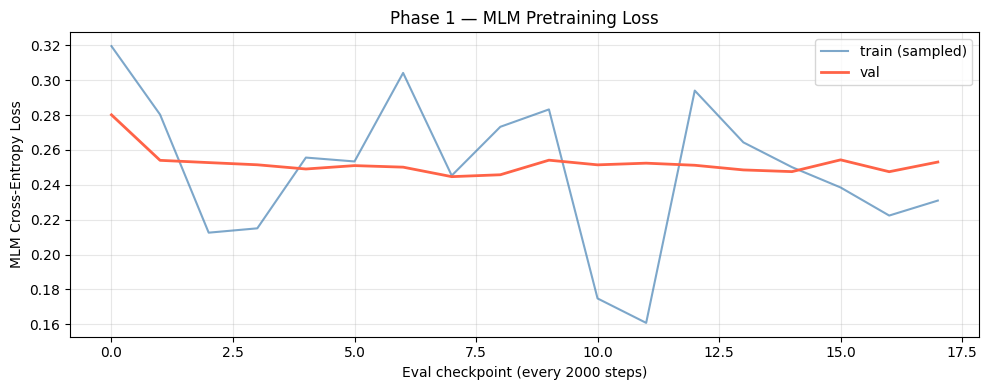

Best val loss: 0.2447

Interpretation:
  Loss ~2.0 = model is learning normal patterns
  Loss ~1.0 = model predicts masked tokens well
  Loss >4.0 = undertrained, need more epochs or data


In [ ]:
# Loss curves
if p1_train_losses:
    plt.figure(figsize=(10, 4))
    plt.plot(p1_train_losses, 'steelblue', label='train (sampled)', alpha=0.7)
    plt.plot(p1_val_losses,   'tomato',    label='val',             linewidth=2)
    plt.xlabel(f'Eval checkpoint (every {P1_EVAL_EVERY} steps)')
    plt.ylabel('MLM Cross-Entropy Loss')
    plt.title('Phase 1 — MLM Pretraining Loss')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    print(f'Best val loss: {best_val_loss_p1:.4f}')
    print('\nInterpretation:')
    print('  Loss ~2.0 = model is learning normal patterns')
    print('  Loss ~1.0 = model predicts masked tokens well')
    print('  Loss >4.0 = undertrained, need more epochs or data')

---
# PART 6 — Anomaly Detection (Phase 1 Output)

Before moving to supervised fine-tuning, we can already use the pretrained model
for anomaly detection — same principle as the GPT approach but with richer representations.

```
Anomaly score = MLM reconstruction loss on the session

Low loss  → model predicted masked tokens confidently  → NORMAL  ✅
High loss → model was surprised by the token sequence  → ANOMALY 🚨
```

The MLM score is **better** than GPT's next-token score because:
- It uses bidirectional context (the token AFTER a suspicious event also informs the score)
- Masking different positions gives a more robust average signal
- The encoder's richer representations distinguish subtle deviations better

✅ Loaded Phase 1 checkpoint (val_loss=0.2447)
Calibrating threshold on normal sessions...


Calibrating:   0%|          | 0/500 [00:00<?, ?it/s]


Normal loss distribution:
  mean=0.2904  std=0.2645  min=0.0000  max=1.7930
  Threshold (mean + 2.0σ) = 0.8194


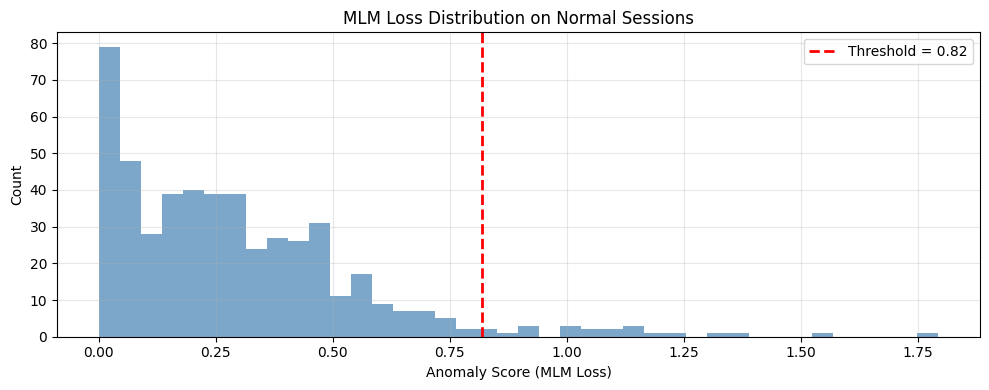

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ANOMALY SCORING — MLM RECONSTRUCTION LOSS
# ─────────────────────────────────────────────────────────────────────────────

# Load best Phase 1 checkpoint
model.load_state_dict(torch.load('bert_phase1_best.pt', map_location=device))
model.eval()
print(f'✅ Loaded Phase 1 checkpoint (val_loss={best_val_loss_p1:.4f})')


@torch.no_grad()
def anomaly_score(log_text: str,
                  n_passes: int = 5,
                  mlm_prob: float = 0.15) -> float:
    """
    Compute anomaly score for a log session.

    Uses multiple masking passes and averages the MLM loss.
    Averaging over multiple passes gives a more stable score
    than a single masking (which might mask easy or hard tokens by chance).

    Returns: float (higher = more anomalous)
    """
    enc   = tokenizer.encode(log_text, max_length=128)
    ids   = enc['input_ids']
    mask  = enc['attention_mask']

    special_ids = {tokenizer.pad_id, tokenizer.cls_id,
                   tokenizer.sep_id, tokenizer.mask_id}
    losses = []

    for _ in range(n_passes):
        masked_ids = list(ids)
        labels     = [-100] * len(ids)

        for i, (tid, is_real) in enumerate(zip(ids, mask)):
            if not is_real or tid in special_ids: continue
            if random.random() < mlm_prob:
                labels[i]     = tid
                masked_ids[i] = tokenizer.mask_id

        # If nothing got masked, score 0 (no information to evaluate)
        if all(l == -100 for l in labels):
            continue

        x_ids  = torch.tensor([masked_ids], dtype=torch.long, device=device)
        x_mask = torch.tensor([mask],       dtype=torch.long, device=device)
        x_lbl  = torch.tensor([labels],     dtype=torch.long, device=device)

        with ctx:
            loss, _ = model.forward_mlm(x_ids, x_mask, mlm_labels=x_lbl)
        if loss is not None:
            losses.append(loss.item())

    return float(np.mean(losses)) if losses else 0.0


# ── Threshold calibration ─────────────────────────────────────────────────────
# Run on 500 known-normal sessions, build distribution, set threshold at mean + 2σ

print('Calibrating threshold on normal sessions...')
cal_sessions = []
with open('pretrain.jsonl') as f:
    for i, line in enumerate(f):
        if i >= 500: break
        cal_sessions.append(json.loads(line)['text'])

cal_scores = np.array([anomaly_score(s) for s in tqdm(cal_sessions, desc='Calibrating')])

MEAN_SCORE = cal_scores.mean()
STD_SCORE  = cal_scores.std()
SIGMA_MULT = 2.0
THRESHOLD  = MEAN_SCORE + SIGMA_MULT * STD_SCORE

print(f'\nNormal loss distribution:')
print(f'  mean={MEAN_SCORE:.4f}  std={STD_SCORE:.4f}  min={cal_scores.min():.4f}  max={cal_scores.max():.4f}')
print(f'  Threshold (mean + {SIGMA_MULT}σ) = {THRESHOLD:.4f}')

plt.figure(figsize=(10, 4))
plt.hist(cal_scores, bins=40, color='steelblue', alpha=0.7)
plt.axvline(THRESHOLD, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {THRESHOLD:.2f}')
plt.xlabel('Anomaly Score (MLM Loss)'); plt.ylabel('Count')
plt.title('MLM Loss Distribution on Normal Sessions')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# ── Test: Normal vs Attack sessions ───────────────────────────────────────────

TEST_SESSIONS = [
    ('Normal: office work',      'NORMAL',
     '[SESSION_START] user=jsmith host=ws-042 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[FILE_READ] path=[WIN_PATH] proc=outlook.exe '
     '[NET_CONN] dst=[IPV4] [PORT] proc=chrome.exe [USER_LOGOUT] [SESSION_END]'),

    ('Normal: admin LDAP',       'NORMAL',
     '[SESSION_START] user=agarcia host=srv-dc01 [TIMESTAMP] [USER_LOGIN] auth=kerberos '
     '[PROC_CREATE] proc=mmc.exe parent=svchost.exe '
     '[NET_CONN] dst=[IPV4] port=389 proc=mmc.exe [USER_LOGOUT] [SESSION_END]'),

    ('Normal: dev git push',     'NORMAL',
     '[SESSION_START] user=blee host=ws-117 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[PROC_CREATE] proc=code.exe parent=explorer.exe '
     '[FILE_WRITE] path=[WIN_PATH] proc=code.exe '
     '[NET_CONN] dst=[DOMAIN] port=443 proc=git.exe [USER_LOGOUT] [SESSION_END]'),

    ('ATTACK: C2 beacon T1071',  'ANOMALY',
     '[SESSION_START] user=jsmith host=ws-042 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[PROC_CREATE] proc=[LOLBIN] parent=outlook.exe '
     '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN] [PROTO] '
     '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN] '
     '[DNS_QUERY] dst=[DOMAIN] proc=[LOLBIN]'),

    ('ATTACK: ransomware T1486', 'ANOMALY',
     '[SESSION_START] user=mwong host=ws-203 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[PROC_CREATE] proc=[LOLBIN] parent=cmd.exe '
     + '[FILE_WRITE] path=[WIN_PATH] proc=[LOLBIN] ' * 12 +
     '[FILE_DELETE] path=[WIN_PATH] proc=[LOLBIN] '
     '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN]'),

    ('ATTACK: phishing T1566',   'ANOMALY',
     '[SESSION_START] user=rthomas host=ws-042 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[PROC_CREATE] proc=mshta.exe parent=outlook.exe '
     '[PROC_CREATE] proc=[LOLBIN] parent=mshta.exe '
     '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN] '
     '[REGISTRY_WRITE] key=[REG_PATH] proc=[LOLBIN]'),

    ('ATTACK: lateral SMB T1021','ANOMALY',
     '[SESSION_START] user=jsmith host=ws-042 [TIMESTAMP] [USER_LOGIN] auth=password '
     + '[NET_CONN] dst=[IPV4] port=445 proc=explorer.exe ' * 6 +
     '[PROC_CREATE] proc=[LOLBIN] parent=explorer.exe'),
]

print(f'Threshold: {THRESHOLD:.4f}\n')
print(f'{"Description":<35} {"Score":>6}  {"Pred":>7}  {"Exp":>7}  ✓?')
print('─' * 68)
correct = 0
for desc, expected, log in TEST_SESSIONS:
    score  = anomaly_score(log)
    sigmas = (score - MEAN_SCORE) / STD_SCORE if STD_SCORE > 0 else 0
    pred   = 'ANOMALY' if score >= THRESHOLD else 'NORMAL'
    ok     = '✓' if pred == expected else '✗'
    if pred == expected: correct += 1
    print(f'{desc:<35} {score:>6.3f}  {pred:>7}  {expected:>7}  {ok}  ({sigmas:+.1f}σ)')

print('─' * 68)
print(f'Accuracy: {correct}/{len(TEST_SESSIONS)}')

Threshold: 0.8194

Description                          Score     Pred      Exp  ✓?
────────────────────────────────────────────────────────────────────
Normal: office work                  0.467   NORMAL   NORMAL  ✓  (+0.7σ)
Normal: admin LDAP                   0.001   NORMAL   NORMAL  ✓  (-1.1σ)
Normal: dev git push                 0.001   NORMAL   NORMAL  ✓  (-1.1σ)
ATTACK: C2 beacon T1071             19.316  ANOMALY  ANOMALY  ✓  (+71.9σ)
ATTACK: ransomware T1486            16.992  ANOMALY  ANOMALY  ✓  (+63.1σ)
ATTACK: phishing T1566              22.260  ANOMALY  ANOMALY  ✓  (+83.1σ)
ATTACK: lateral SMB T1021            9.505  ANOMALY  ANOMALY  ✓  (+34.8σ)
────────────────────────────────────────────────────────────────────
Accuracy: 7/7


---
# PART 7 — Phase 2: Supervised Fine-tuning

## What happens
```
1. Load Phase 1 pretrained weights (encoder already understands normal log patterns)
2. Attach classification heads to the [CLS] vector
3. Train on labeled data (70k sessions with threat/severity/confidence/tp/surface labels)
4. Loss = weighted sum of all 5 task losses
5. MLM head is no longer used — only [CLS] → classification heads
```

## Why Phase 1 weights help Phase 2
```
Without Phase 1 (random init):    encoder sees 70k labeled examples from scratch
With Phase 1 (pretrained):        encoder already encodes rich log semantics,
                                   fine-tuning just teaches it to NAME the threats
```

This is the key advantage over the old GPT + separate encoder approach — no wasted learning.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FINE-TUNING DATASET
# ─────────────────────────────────────────────────────────────────────────────

class FineTuneDataset(Dataset):
    def __init__(self, jsonl_path: str, tokenizer: SecurityBERTTokenizer,
                 max_length: int = 128):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.samples    = []

        with open(jsonl_path) as f:
            for line in f:
                self.samples.append(json.loads(line))

        print(f'[FineTuneDataset] Loaded {len(self.samples):,} labeled sessions from {jsonl_path}')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        enc = self.tokenizer.encode(s['text'], self.max_length)
        return {
            'input_ids':        torch.tensor(enc['input_ids'],      dtype=torch.long),
            'attention_mask':   torch.tensor(enc['attention_mask'], dtype=torch.long),
            'token_type_ids':   torch.tensor(enc['token_type_ids'], dtype=torch.long),
            'threat_labels':    torch.tensor(s['threat_label'],     dtype=torch.long),
            'severity_labels':  torch.tensor(s['severity_label'],   dtype=torch.long),
            'conf_labels':      torch.tensor(s['confidence_label'], dtype=torch.long),
            'tp_labels':        torch.tensor(s['tp_label'],         dtype=torch.long),
            'surface_labels':   torch.tensor(s['surface_labels'],   dtype=torch.float),
        }


# Datasets
train_ft_ds = FineTuneDataset('finetune_train.jsonl', tokenizer)
val_ft_ds   = FineTuneDataset('finetune_val.jsonl',   tokenizer)

P2_BATCH_SIZE = 64
train_loader_p2 = DataLoader(train_ft_ds, batch_size=P2_BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=(device=='cuda'))
val_loader_p2   = DataLoader(val_ft_ds,   batch_size=P2_BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=(device=='cuda'))

print(f'Batches: {len(train_loader_p2):,} train | {len(val_loader_p2):,} val')

[FineTuneDataset] Loaded 70,000 labeled sessions from finetune_train.jsonl
[FineTuneDataset] Loaded 30,000 labeled sessions from finetune_val.jsonl
Batches: 1,094 train | 469 val


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 TRAINING — SUPERVISED FINE-TUNING
# ─────────────────────────────────────────────────────────────────────────────

P2_EPOCHS        = 5
P2_LR            = 2e-5    # lower LR for fine-tuning (don't destroy Phase 1 weights)
P2_WARMUP_STEPS  = 500
P2_EVAL_EVERY    = 500

# Load Phase 1 weights
model.load_state_dict(torch.load('bert_phase1_best.pt', map_location=device))
print('✅ Phase 1 weights loaded into model')

# Lower LR for encoder (preserve pretrained knowledge), higher for new heads
encoder_params = list(model.encoder.parameters()) + list(model.tok_emb.parameters()) + \
                 list(model.pos_emb.parameters()) + list(model.seg_emb.parameters())
head_params    = (list(model.threat_head.parameters()) + list(model.severity_head.parameters()) +
                  list(model.conf_head.parameters())   + list(model.tp_head.parameters()) +
                  list(model.surface_head.parameters()))

optimizer_p2 = torch.optim.AdamW([
    {'params': encoder_params, 'lr': P2_LR},          # encoder: gentle updates
    {'params': head_params,    'lr': P2_LR * 10},      # heads: faster learning (random init)
], betas=(0.9, 0.98), weight_decay=0.01)

total_steps_p2 = len(train_loader_p2) * P2_EPOCHS
scheduler_p2   = SequentialLR(optimizer_p2, schedulers=[
    LinearLR(optimizer_p2, start_factor=0.1, total_iters=P2_WARMUP_STEPS),
    CosineAnnealingLR(optimizer_p2, T_max=total_steps_p2 - P2_WARMUP_STEPS, eta_min=1e-6)
], milestones=[P2_WARMUP_STEPS])


@torch.no_grad()
def eval_classify(loader, max_batches=50):
    model.eval()
    total_loss = 0.0
    all_threat_pred, all_threat_true = [], []
    all_tp_pred, all_tp_true         = [], []
    n = 0

    for i, batch in enumerate(loader):
        if i >= max_batches: break
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        segs = batch['token_type_ids'].to(device)

        with ctx:
            total, losses, logits = model.forward_classify(
                ids, mask, segs,
                threat_labels=batch['threat_labels'].to(device),
                severity_labels=batch['severity_labels'].to(device),
                confidence_labels=batch['conf_labels'].to(device),
                tp_labels=batch['tp_labels'].to(device),
                surface_labels=batch['surface_labels'].to(device),
            )

        total_loss += total.item()
        all_threat_pred.extend(logits['threat'].argmax(-1).cpu().tolist())
        all_threat_true.extend(batch['threat_labels'].tolist())
        all_tp_pred.extend((torch.sigmoid(logits['tp']) > 0.5).cpu().long().tolist())
        all_tp_true.extend(batch['tp_labels'].tolist())
        n += 1

    threat_acc = np.mean(np.array(all_threat_pred) == np.array(all_threat_true))
    tp_acc     = np.mean(np.array(all_tp_pred)     == np.array(all_tp_true))
    model.train()
    return total_loss / n, threat_acc, tp_acc


# ── Training loop ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('PHASE 2 — SUPERVISED FINE-TUNING')
print('='*60)

best_val_loss_p2 = float('inf')
p2_train_losses, p2_val_losses = [], []
global_step_p2 = 0

for epoch in range(P2_EPOCHS):
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader_p2, desc=f'Epoch {epoch+1}/{P2_EPOCHS}')

    for batch in pbar:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        segs = batch['token_type_ids'].to(device)

        with ctx:
            total, losses, _ = model.forward_classify(
                ids, mask, segs,
                threat_labels=batch['threat_labels'].to(device),
                severity_labels=batch['severity_labels'].to(device),
                confidence_labels=batch['conf_labels'].to(device),
                tp_labels=batch['tp_labels'].to(device),
                surface_labels=batch['surface_labels'].to(device),
            )

        scaler.scale(total).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer_p2)
        scaler.update()
        optimizer_p2.zero_grad(set_to_none=True)
        scheduler_p2.step()

        epoch_loss    += total.item()
        global_step_p2+= 1
        pbar.set_postfix({
            'loss':    f'{total.item():.4f}',
            'threat':  f'{losses.get("threat", 0):.3f}',
            'tp':      f'{losses.get("tp", 0):.3f}',
        })

        if global_step_p2 % P2_EVAL_EVERY == 0:
            val_loss, threat_acc, tp_acc = eval_classify(val_loader_p2)
            p2_train_losses.append(total.item())
            p2_val_losses.append(val_loss)
            print(f'  Step {global_step_p2:5d} | val={val_loss:.4f} '
                  f'| threat_acc={threat_acc:.3f} | tp_acc={tp_acc:.3f}')
            if val_loss < best_val_loss_p2:
                best_val_loss_p2 = val_loss
                torch.save(model.state_dict(), 'bert_phase2_best.pt')
                print(f'    ✅ Saved phase2 checkpoint (val={best_val_loss_p2:.4f})')

    avg = epoch_loss / len(train_loader_p2)
    print(f'Epoch {epoch+1} done | avg_loss={avg:.4f}')

print(f'\n✅ Phase 2 complete. Best val loss: {best_val_loss_p2:.4f}')

✅ Phase 1 weights loaded into model

PHASE 2 — SUPERVISED FINE-TUNING


Epoch 1/5:   0%|          | 0/1094 [00:00<?, ?it/s]

  Step   500 | val=0.2544 | threat_acc=1.000 | tp_acc=1.000
    ✅ Saved phase2 checkpoint (val=0.2544)
  Step  1000 | val=0.2406 | threat_acc=1.000 | tp_acc=1.000
    ✅ Saved phase2 checkpoint (val=0.2406)
Epoch 1 done | avg_loss=0.4025


Epoch 2/5:   0%|          | 0/1094 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c319d41ea20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c319d41ea20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Epoch 4/5:   0%|          | 0/1094 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c319d41ea20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c319d41ea20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Step  3500 | val=0.2392 | threat_acc=1.000 | tp_acc=1.000
    ✅ Saved phase2 checkpoint (val=0.2392)
  Step  4000 | val=0.2392 | threat_acc=1.000 | tp_acc=1.000
    ✅ Saved phase2 checkpoint (val=0.2392)
Epoch 4 done | avg_loss=0.2392


Epoch 5/5:   0%|          | 0/1094 [00:00<?, ?it/s]

  Step  4500 | val=0.2392 | threat_acc=1.000 | tp_acc=1.000
  Step  5000 | val=0.2392 | threat_acc=1.000 | tp_acc=1.000
Epoch 5 done | avg_loss=0.2392

✅ Phase 2 complete. Best val loss: 0.2392


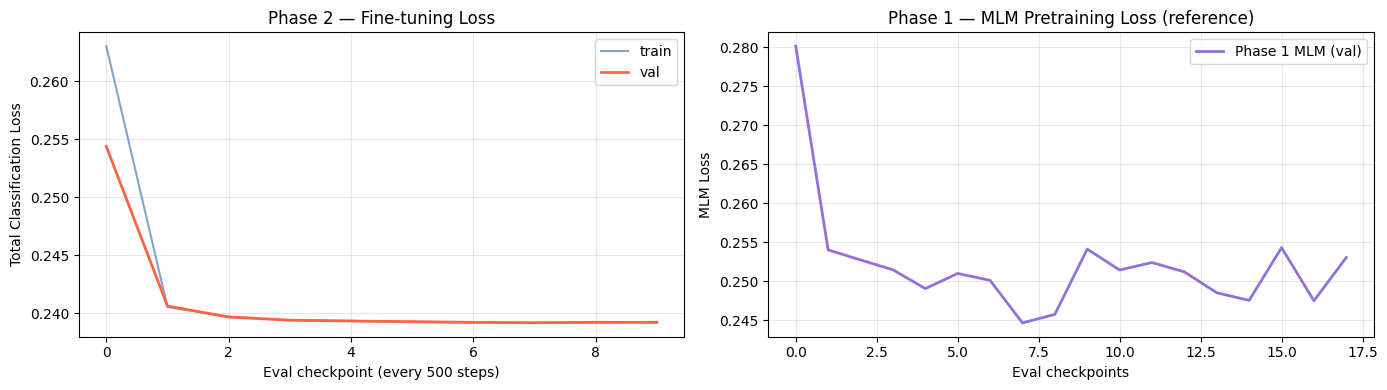

In [ ]:
# Phase 2 loss curves
if p2_train_losses:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(p2_train_losses, 'steelblue', label='train', alpha=0.7)
    ax1.plot(p2_val_losses,   'tomato',    label='val',   linewidth=2)
    ax1.set_xlabel(f'Eval checkpoint (every {P2_EVAL_EVERY} steps)')
    ax1.set_ylabel('Total Classification Loss')
    ax1.set_title('Phase 2 — Fine-tuning Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(p1_val_losses, 'mediumpurple', label='Phase 1 MLM (val)', linewidth=2)
    ax2.set_xlabel('Eval checkpoints'); ax2.set_ylabel('MLM Loss')
    ax2.set_title('Phase 1 — MLM Pretraining Loss (reference)')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

---
# PART 8 — Full Detection Pipeline

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FULL DETECTION INTERFACE
#
# This is what your Agentic SOC pipeline calls.
# Combines Phase 1 anomaly score + Phase 2 classification in one call.
# ─────────────────────────────────────────────────────────────────────────────

# Load best Phase 2 model
model.load_state_dict(torch.load('bert_phase2_best.pt', map_location=device))
model.eval()
print('✅ Loaded Phase 2 checkpoint for inference')


def detect(raw_log: str) -> dict:
    """
    Full detection pipeline for Agentic SOC.

    Stage 1: Anomaly score (MLM loss) — is this unusual?
    Stage 2: Classification — what is it, how severe, how confident?

    Returns structured alert dict.
    """
    # Stage 1: Anomaly detection
    score    = anomaly_score(raw_log)
    sigmas   = (score - MEAN_SCORE) / STD_SCORE if STD_SCORE > 0 else 0.0
    is_anomaly = score >= THRESHOLD

    result = {
        'anomaly_score':  round(score, 4),
        'is_anomaly':     is_anomaly,
        'threshold':      round(THRESHOLD, 4),
        'sigmas_above':   round(sigmas, 2),
        # Stage 1 severity estimate (before classification)
        'raw_severity':   'HIGH' if sigmas > 4 else 'MEDIUM' if sigmas > 2 else 'LOW',
    }

    # Stage 2: Only classify if anomalous (saves compute for normal traffic)
    if is_anomaly:
        enc  = tokenizer.encode(raw_log, max_length=128)
        ids  = torch.tensor([enc['input_ids']],      dtype=torch.long, device=device)
        mask = torch.tensor([enc['attention_mask']],  dtype=torch.long, device=device)

        classification = model.predict(ids, mask)
        result.update({
            'threat_category':  classification['threat'],
            'threat_prob':      round(classification['threat_prob'], 3),
            'severity':         classification['severity'],
            'confidence':       classification['confidence'],
            'true_positive':    classification['true_positive'],
            'tp_prob':          round(classification['tp_prob'], 3),
            'attack_surfaces':  classification['attack_surfaces'],
        })
    else:
        result.update({
            'threat_category': None,
            'severity':        'info',
            'confidence':      None,
            'true_positive':   False,
            'attack_surfaces': [],
        })

    return result


# ── Test the full pipeline ─────────────────────────────────────────────────────
TEST_CASES = [
    ('Normal office work',
     '[SESSION_START] user=jsmith host=ws-042 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[FILE_READ] path=[WIN_PATH] proc=outlook.exe '
     '[NET_CONN] dst=[IPV4] [PORT] proc=chrome.exe [USER_LOGOUT] [SESSION_END]'),

    ('Phishing chain (T1566)',
     '[SESSION_START] user=rthomas host=ws-042 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[PROC_CREATE] proc=mshta.exe parent=outlook.exe '
     '[PROC_CREATE] proc=[LOLBIN] parent=mshta.exe '
     '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN] '
     '[REGISTRY_WRITE] key=[REG_PATH] proc=[LOLBIN]'),

    ('Ransomware (T1486)',
     '[SESSION_START] user=mwong host=ws-203 [TIMESTAMP] [USER_LOGIN] auth=password '
     '[PROC_CREATE] proc=[LOLBIN] parent=cmd.exe '
     + '[FILE_WRITE] path=[WIN_PATH] proc=[LOLBIN] ' * 15 +
     '[NET_CONN] dst=[IP_PORT] proc=[LOLBIN]'),

    ('Lateral movement (T1021)',
     '[SESSION_START] user=jsmith host=ws-042 [TIMESTAMP] [USER_LOGIN] auth=password '
     + '[NET_CONN] dst=[IPV4] port=445 proc=explorer.exe ' * 7 +
     '[PROC_CREATE] proc=[LOLBIN] parent=explorer.exe'),
]

for name, log in TEST_CASES:
    result = detect(log)
    print(f'\n[{name}]')
    print(f'  Anomaly:    {result["is_anomaly"]}  (score={result["anomaly_score"]}, {result["sigmas_above"]:+.1f}σ)')
    if result['is_anomaly']:
        print(f'  Threat:     {result["threat_category"]}  (p={result["threat_prob"]:.2f})')
        print(f'  Severity:   {result["severity"]}  |  Confidence: {result["confidence"]}')
        print(f'  True Pos:   {result["true_positive"]}  (p={result["tp_prob"]:.2f})')
        print(f'  Surfaces:   {result["attack_surfaces"]}')

✅ Loaded Phase 2 checkpoint for inference

[Normal office work]
  Anomaly:    True  (score=2.4299, +8.1σ)
  Threat:     policy_violation  (p=0.91)
  Severity:   info  |  Confidence: low
  True Pos:   False  (p=0.00)
  Surfaces:   []

[Phishing chain (T1566)]
  Anomaly:    True  (score=19.0166, +70.8σ)
  Threat:     phishing  (p=0.91)
  Severity:   high  |  Confidence: confirmed
  True Pos:   True  (p=1.00)
  Surfaces:   ['endpoint', 'email']

[Ransomware (T1486)]
  Anomaly:    True  (score=17.3179, +64.4σ)
  Threat:     ransomware  (p=0.92)
  Severity:   critical  |  Confidence: confirmed
  True Pos:   True  (p=1.00)
  Surfaces:   ['endpoint', 'network']

[Lateral movement (T1021)]
  Anomaly:    True  (score=10.2706, +37.7σ)
  Threat:     lateral_movement  (p=0.80)
  Severity:   high  |  Confidence: high
  True Pos:   True  (p=1.00)
  Surfaces:   ['endpoint', 'network', 'identity']


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE DEPLOYMENT BUNDLE
# ─────────────────────────────────────────────────────────────────────────────

deployment = {
    'phase1_model':     'bert_phase1_best.pt',
    'phase2_model':     'bert_phase2_best.pt',
    'tokenizer':        'security_tokenizer.json',
    'threshold':        float(THRESHOLD),
    'mean_score':       float(MEAN_SCORE),
    'std_score':        float(STD_SCORE),
    'sigma_mult':       SIGMA_MULT,
    'model_config': {
        'vocab_size':  bert_config.vocab_size,
        'hidden_size': bert_config.hidden_size,
        'num_layers':  bert_config.num_layers,
        'num_heads':   bert_config.num_heads,
        'max_seq_len': bert_config.max_seq_len,
    },
    'phase1_best_val_loss': float(best_val_loss_p1),
    'phase2_best_val_loss': float(best_val_loss_p2),
    'total_params': sum(p.numel() for p in model.parameters()),
}

with open('detection_config.json', 'w') as f:
    json.dump(deployment, f, indent=2)

print('✅ Deployment bundle saved:')
print('  bert_phase1_best.pt    — Phase 1 MLM pretrained encoder')
print('  bert_phase2_best.pt    — Phase 2 fine-tuned classifier')
print('  security_tokenizer.json — trained BPE tokenizer')
print('  detection_config.json   — threshold + model config')
print()
print(json.dumps(deployment, indent=2))

✅ Deployment bundle saved:
  bert_phase1_best.pt    — Phase 1 MLM pretrained encoder
  bert_phase2_best.pt    — Phase 2 fine-tuned classifier
  security_tokenizer.json — trained BPE tokenizer
  detection_config.json   — threshold + model config

{
  "phase1_model": "bert_phase1_best.pt",
  "phase2_model": "bert_phase2_best.pt",
  "tokenizer": "security_tokenizer.json",
  "threshold": 0.8194198119234806,
  "mean_score": 0.29043426279939255,
  "std_score": 0.264492774562044,
  "sigma_mult": 2.0,
  "model_config": {
    "vocab_size": 8192,
    "hidden_size": 256,
    "num_layers": 6,
    "num_heads": 8,
    "max_seq_len": 128
  },
  "phase1_best_val_loss": 0.24467263728380204,
  "phase2_best_val_loss": 0.2391858822107315,
  "total_params": 9115680
}


In [ ]:
import shutil
import os
from google.colab import files

# Define folder name
folder_name = 'security_bert_v4'
os.makedirs(folder_name, exist_ok=True)

# List of all files to include
files_to_package = [
    'bert_phase1_best.pt',
    'bert_phase2_best.pt',
    'security_tokenizer.json',
    'detection_config.json',
    'pretrain.jsonl',
    'finetune_train.jsonl',
    'finetune_val.jsonl'
]

# Copy files into the folder
print(f'Packaging files into {folder_name}/...')
for filename in files_to_package:
    if os.path.exists(filename):
        shutil.copy(filename, f'{folder_name}/{filename}')
    else:
        print(f'Warning: {filename} not found, skipping.')

# Zip the folder
shutil.make_archive(folder_name, 'zip', folder_name)
print(f'Created {folder_name}.zip')

# Download the zip
try:
    files.download(f'{folder_name}.zip')
except Exception as e:
    print(f'Error downloading zip: {e}')

Packaging files into security_bert_v4/...
Created security_bert_v4.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Switching to real logs

```python
# 1. Export normal sessions from SIEM (for pretrain.jsonl)
#    Format: {"text": "<raw log session string>"}
#    One JSON object per line, one session per line
#    A session = sequence of events for one user/host/time-window

# 2. Export labeled incidents (for finetune_train/val.jsonl)
#    Format: {"text": "...", "threat_label": 0-13, "severity_label": 0-4,
#             "confidence_label": 0-3, "tp_label": 0/1, "surface_labels": [0,1,0,...]}
#    Source: closed SOC tickets, threat intel enrichment, analyst labels

# 3. Re-train tokenizer on real pretrain data
#    tokenizer = SecurityBERTTokenizer(vocab_size=8192)
#    tokenizer.train(real_texts)
#    tokenizer.save('security_tokenizer_real.json')

# 4. Re-run Phase 1 on real normal data (replace synthetic pretrain.jsonl)
# 5. Re-run Phase 2 on real labeled data (replace synthetic finetune_*.jsonl)
# 6. Re-calibrate threshold on real validation set
```

## Threshold tuning
```
SIGMA_MULT = 3.0  → fewer alerts, lower FP rate, might miss subtle attacks
SIGMA_MULT = 2.0  → balanced default
SIGMA_MULT = 1.5  → more alerts, catches edge cases, higher FP rate
```

## Architecture summary
```
One model, two training phases, one inference function.

Phase 1 (MLM pretrain) → Phase 2 (fine-tune) → detect()
     ↑                        ↑                     ↑
No labels needed          Needs labeled data    Returns both
Train on 900k sessions    Train on 100k         anomaly score +
                          labeled sessions      classification
```